In [1]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import random
import pandas as pd


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
SEED = 123

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)


ood_generator = torch.Generator(
    device=device
)

ood_generator.manual_seed(SEED)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)


#DATA

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

svhn_test = torchvision.datasets.SVHN(
    root="./data",
    split="test",
    download=True,
    transform=transform
)


In [5]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, generator=loader_generator)

test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

svhn_loader = DataLoader(svhn_test, batch_size=64, shuffle=False)

## Additional OOD data: CIFAR-100

CIFAR-100 test is used as a near-OOD evaluation set for the CIFAR-10 classifier.
CIFAR-100 train is kept available as a separate auxiliary OOD source for training.

In [6]:
cifar100_train = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform
)

cifar100_test = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform
)

cifar100_train_loader = DataLoader(
    cifar100_train, batch_size=64, shuffle=True, generator=loader_generator
)

cifar100_test_loader = DataLoader(
    cifar100_test, batch_size=64, shuffle=False
)

#UTILS

In [7]:
def sample_uniform_ood(
    batch_size,
    device,
    image_size=(3, 32, 32)
):

    return torch.rand(
        batch_size,
        *image_size,
        device=device,
        generator=ood_generator
    )


def shift_labels(y):

    return y + 1


def get_probs(logits, mode):

    if mode == "onehot":
        return torch.sigmoid(logits)

    return torch.softmax(logits, dim=1)



In [8]:
def extract_features(model, loader, device):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            feats = model(x)

            features.append(feats.cpu())
            labels.append(y)

    return (
        torch.cat(features),
        torch.cat(labels)
    )

## Train loops

In [9]:
def train_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    mode="softmax"
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for x, y in loop:

        x = x.to(device)
        y = y.to(device)

        if mode == "onehot":
            targets = F.one_hot(
                y,
                num_classes=model.head.out_features
            ).float()

        else:
            targets = y

        logits = model(x)

        loss = criterion(
            logits,
            targets
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if hasattr(model, "update_statistics"):
            embeddings = model.extract_embedding(x)
            model.update_statistics(
                embeddings,
                y
            )

        probs = get_probs(
            logits,
            mode
        )

        preds = probs.argmax(dim=1)

        correct += (
            preds == y
        ).sum().item()

        total += y.size(0)

        total_loss += loss.item()

        loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    return {
        "loss": total_loss / len(loader),
        "acc": correct / total
    }

In [10]:
def train_epoch_with_ood(
    model,
    loader,
    criterion,
    optimizer,
    device,
    mode="softmax",
    ood_ratio=1.0
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader)

    for x_id, y_id in loop:

        x_id = x_id.to(device)
        y_id = y_id.to(device)

        batch_size = x_id.size(0)

        if mode == "softmax":

            y_id_targets = shift_labels(y_id)

        elif mode == "onehot":

            y_id_targets = F.one_hot(
                y_id,
                num_classes=model.head.out_features
            ).float()

        ood_batch_size = int(
            batch_size * ood_ratio
        )

        x_ood = sample_uniform_ood(
            ood_batch_size,
            device
        )

        if mode == "softmax":

            y_ood_targets = torch.zeros(
                ood_batch_size,
                dtype=torch.long,
                device=device
            )

        elif mode == "onehot":

            y_ood_targets = torch.zeros(
                ood_batch_size,
                model.head.out_features,
                device=device
            )


        x = torch.cat([
            x_id,
            x_ood
        ], dim=0)

        y = torch.cat([
            y_id_targets,
            y_ood_targets
        ], dim=0)

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if hasattr(model, "update_statistics"):
            embeddings = model.extract_embedding(x)
            model.update_statistics(
                embeddings,
                y
            )

        probs_id = get_probs(
            logits[:batch_size],
            mode
        )

        preds_id = probs_id.argmax(dim=1)

        correct += (
            preds_id == y_id
        ).sum().item()

        total += batch_size

        total_loss += loss.item()

        loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    return {
        "loss": total_loss / len(loader),
        "acc": correct / total
    }


In [11]:
def fit(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    mode="softmax",
    use_ood=False,
    ood_ratio=1.0
):

    history = []

    for epoch in range(epochs):

        if use_ood:

            metrics = train_epoch_with_ood(
                model=model,
                loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                mode=mode,
                ood_ratio=ood_ratio
            )

        else:

            metrics = train_epoch(
                model=model,
                loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                device=device,
                mode=mode
            )

        history.append(metrics)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"loss={metrics['loss']:.4f} | "
            f"acc={metrics['acc']:.4f}"
        )

    return history

##Evaluate

In [12]:
def evaluate_model(
    model,
    loader,
    device,
    mode="softmax",
    ood_class=False
):

    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            logits = model(x)

            probs = get_probs(logits, mode)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())

            if ood_class:
                y = shift_labels(y)
            all_labels.append(y)

    probs = torch.cat(all_probs)
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    return {
        "probs": probs,
        "preds": preds,
        "labels": labels
    }

In [13]:
def progressive_training_evaluation(
    model,
    criterion,
    optimizer,
    train_loader,
    id_loader,
    ood_loader,
    device,
    steps=10,
    train_steps=10,
    ood_mode=True,
    model_mode='softmax',
    ood_ratio=1.0,
    score_mode="msp"
):

    fr_list = []
    orr_list = []

    for step in range(steps):

        fit(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epochs=train_steps,
            mode=model_mode,
            use_ood=ood_mode,
            ood_ratio=ood_ratio)

        id_scores = evaluate_model(
            model=model,
            loader=id_loader,
            device=device,
            mode=model_mode)
        ood_scores = evaluate_model(
            model=model,
            loader=ood_loader,
            device=device,
            mode=model_mode)

        computed = compute_reject_curves(id_scores["probs"], ood_scores["probs"], score_mode=score_mode)

        thresholds, fr, orr = computed["thresholds"], computed["false_reject"], computed["ood_reject"]

        fr_list.append(fr.mean())
        orr_list.append(orr.mean())
        print(f"step: {step+1}/{steps}: \n\tFR = {fr.mean()}\n\tORR = {orr.mean()}\n" + "="*20)

    return fr_list, orr_list

##Metrics

In [14]:
def classification_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": cm
    }

In [15]:
def compute_entropy(probs):

    return -torch.sum(
        probs * torch.log(probs + 1e-8),
        dim=1
    )


def compute_msp(probs):

    return probs.max(dim=1).values

In [16]:
def prepare_ood_labels(id_scores, ood_scores):

    labels = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores))
    ])

    scores = np.concatenate([
        id_scores,
        ood_scores
    ])

    return labels, scores

In [17]:
def compute_ood_metrics(
    id_probs,
    ood_probs
):

    entropy_id = compute_entropy(id_probs)
    entropy_ood = compute_entropy(ood_probs)

    msp_id = compute_msp(id_probs)
    msp_ood = compute_msp(ood_probs)

    labels_entropy, scores_entropy = prepare_ood_labels(
        entropy_id.numpy(),
        entropy_ood.numpy()
    )

    labels_msp, scores_msp = prepare_ood_labels(
        (-msp_id).numpy(),
        (-msp_ood).numpy()
    )

    auroc_entropy = roc_auc_score(
        labels_entropy,
        scores_entropy
    )

    auroc_msp = roc_auc_score(
        labels_msp,
        scores_msp
    )

    fpr_entropy, tpr_entropy, _ = roc_curve(
        labels_entropy,
        scores_entropy
    )

    fpr_msp, tpr_msp, _ = roc_curve(
        labels_msp,
        scores_msp
    )

    return {
        "entropy": {
            "id": entropy_id,
            "ood": entropy_ood,
            "auroc": auroc_entropy,
            "fpr": fpr_entropy,
            "tpr": tpr_entropy
        },

        "msp": {
            "id": msp_id,
            "ood": msp_ood,
            "auroc": auroc_msp,
            "fpr": fpr_msp,
            "tpr": tpr_msp
        }
    }


## Modern OOD scoring baselines

The ordinary 10-class softmax `basemodel` is evaluated with Energy and ODIN in addition to MSP and entropy.
These are scoring baselines, so no architectural change is required.

In [18]:
def compute_energy(logits, temperature=1.0):
    return -temperature * torch.logsumexp(logits / temperature, dim=1)


def energy_ood_scores(logits, temperature=1.0):
    return compute_energy(logits, temperature)


def evaluate_logits(model, loader, device):
    model.eval()
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for x, y in loader:
            logits_all.append(model(x.to(device)).cpu())
            labels_all.append(y)

    return torch.cat(logits_all), torch.cat(labels_all)


def compute_score_auroc(id_scores, ood_scores):
    labels, scores = prepare_ood_labels(id_scores, ood_scores)
    return roc_auc_score(labels, scores)


def odin_ood_scores(
    model,
    loader,
    device,
    temperature=1000.0,
    epsilon=0.0014
):
    model.eval()
    scores = []

    for x, _ in loader:
        x = x.to(device)
        x.requires_grad_(True)

        logits = model(x)
        scaled_logits = logits / temperature
        pseudo_labels = scaled_logits.argmax(dim=1)

        loss = F.cross_entropy(scaled_logits, pseudo_labels)

        model.zero_grad(set_to_none=True)
        loss.backward()

        gradient = x.grad.detach().sign()
        x_perturbed = (x.detach() - epsilon * gradient).clamp(0.0, 1.0)

        with torch.no_grad():
            perturbed_logits = model(x_perturbed)
            probs = torch.softmax(perturbed_logits / temperature, dim=1)
            scores.append(probs.max(dim=1).values.cpu())

    return torch.cat(scores)


def evaluate_modern_scores(
    model,
    id_loader,
    ood_loader,
    device,
    energy_temperature=1.0,
    odin_temperature=1000.0,
    odin_epsilon=0.0014
):
    id_logits, _ = evaluate_logits(model, id_loader, device)
    ood_logits, _ = evaluate_logits(model, ood_loader, device)

    id_energy = energy_ood_scores(
        id_logits, energy_temperature
    ).numpy()
    ood_energy = energy_ood_scores(
        ood_logits, energy_temperature
    ).numpy()

    id_odin = odin_ood_scores(
        model, id_loader, device, odin_temperature, odin_epsilon
    ).numpy()
    ood_odin = odin_ood_scores(
        model, ood_loader, device, odin_temperature, odin_epsilon
    ).numpy()

    return {
        "Energy AUROC": compute_score_auroc(id_energy, ood_energy),
        "ODIN AUROC": compute_score_auroc(-id_odin, -ood_odin),
        "energy_id": id_energy,
        "energy_ood": ood_energy,
        "odin_id": id_odin,
        "odin_ood": ood_odin
    }

In [19]:
def compute_reject_curves(
    id_probs,
    ood_probs,
    model_name="Model",
    n_thresholds=50,
    score_mode="msp"
    ):
    if score_mode == "msp":
        id_scores = compute_msp(id_probs).cpu().numpy()
        ood_scores = compute_msp(ood_probs).cpu().numpy()
    elif score_mode == "entropy":
        id_scores = compute_entropy(id_probs).cpu().numpy()
        ood_scores = compute_entropy(ood_probs).cpu().numpy()


    thresholds = np.linspace(0.0, 1.0, n_thresholds)

    false_reject_rates = []
    ood_reject_rates = []

    loop = tqdm(thresholds, desc=f"{model_name} reject curves")

    for t in loop:
        if score_mode == "msp":
            fr = np.mean(id_scores < t)
            orr = np.mean(ood_scores < t)
        elif score_mode == "entropy":
            fr = np.mean(id_scores > t)
            orr = np.mean(ood_scores > t)

        false_reject_rates.append(fr)
        ood_reject_rates.append(orr)


    return {
        "thresholds": thresholds,
        "false_reject": np.array(false_reject_rates),
        "ood_reject": np.array(ood_reject_rates)
    }

##Plotting

In [20]:
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(6, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title)

    plt.show()

In [21]:
def plot_ood_distributions(
    id_scores,
    ood_scores,
    title,
    xlabel
):

    plt.figure(figsize=(8, 5))

    plt.hist(
        id_scores,
        bins=50,
        alpha=0.6,
        label="ID"
    )

    plt.hist(
        ood_scores,
        bins=50,
        alpha=0.6,
        label="OOD"
    )

    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.title(title)

    plt.legend()

    plt.show()

In [22]:
def plot_ood_roc(
    fpr,
    tpr,
    auroc,
    title
):

    plt.figure(figsize=(6, 6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUROC = {auroc:.4f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.show()

In [23]:
def evaluate_ood(
    id_probs,
    ood_probs,
    model_name="Model"
):

    metrics = compute_ood_metrics(
        id_probs,
        ood_probs
    )

    plot_ood_distributions(
        metrics["entropy"]["id"].numpy(),
        metrics["entropy"]["ood"].numpy(),
        title=f"{model_name}: Entropy Distribution",
        xlabel="Entropy"
    )

    plot_ood_distributions(
        metrics["msp"]["id"].numpy(),
        metrics["msp"]["ood"].numpy(),
        title=f"{model_name}: MSP Distribution",
        xlabel="MSP"
    )

    plot_ood_roc(
        metrics["entropy"]["fpr"],
        metrics["entropy"]["tpr"],
        metrics["entropy"]["auroc"],
        title=f"{model_name}: ROC (Entropy)"
    )

    plot_ood_roc(
        metrics["msp"]["fpr"],
        metrics["msp"]["tpr"],
        metrics["msp"]["auroc"],
        title=f"{model_name}: ROC (MSP)"
    )

    print(f"{model_name} OOD Metrics")
    print("-" * 40)

    print(
        f"Entropy AUROC: "
        f"{metrics['entropy']['auroc']:.4f}"
    )

    print(
        f"MSP AUROC: "
        f"{metrics['msp']['auroc']:.4f}"
    )

    return metrics

In [24]:
def plot_reject_curve(
        ax,
        id_probs,
        ood_probs,
        model_name="Model",
        score_mode="msp",
        n_thresholds=50
    ):
    computed = compute_reject_curves(
        id_probs,
        ood_probs,
        model_name=model_name,
        score_mode=score_mode,
        n_thresholds=n_thresholds)

    thresholds, false_reject_rates, ood_reject_rates = computed["thresholds"], computed["false_reject"], computed["ood_reject"]

    ax.plot(
        thresholds,
        false_reject_rates,
        label="False Reject Rate (ID)"
    )

    ax.plot(
        thresholds,
        ood_reject_rates,
        label="OOD Reject Rate"
    )
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Reject Rate")

    ax.set_title(f"{model_name}: Reject Rates vs Threshold on {score_mode}")

    ax.legend()
    ax.grid(True)

def plot_reject_curves(
        id_probs,
        ood_probs,
        model_name="Model",
        n_thresholds=50
    ):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_reject_curve(
        ax=axes[0],
        id_probs=id_probs,
        ood_probs=ood_probs,
        model_name=model_name,
        score_mode="msp",
        n_thresholds=50)
    plot_reject_curve(
        ax=axes[1],
        id_probs=id_probs,
        ood_probs=ood_probs,
        model_name=model_name,
        score_mode="entropy",
        n_thresholds=50)
    plt.show()



In [25]:
def plot_reject_rate_by_epochs(epochs, fr_list, orr_list, model):
    plt.figure(figsize=(10, 6))

    plt.plot(
        range(*epochs),
        fr_list,
        label="False Reject Rate (ID)"
    )
    plt.plot(
        range(*epochs),
        orr_list,
        label="OOD Reject Rate"
    )



    plt.xlabel("Epochs")
    plt.ylabel("Reject Rate")

    plt.title(f"{model}: Reject Rates with progress")

    plt.legend()
    plt.grid(True)

    plt.show()

#MODEL WITHOUT OOD CLASS

## BASELINE

In [26]:
class FeatureCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

##HEADS

###Baseline

In [27]:
class CNN_SOFTMAX(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = FeatureCNN()
        self.head = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

In [28]:
basemodel = CNN_SOFTMAX().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    basemodel.parameters(),
    lr=1e-3
)

fit(
    model=basemodel,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=False
)

results_base = evaluate_model(
    basemodel,
    test_loader,
    device
)

metrics_base = classification_metrics(
    results_base["labels"].numpy(),
    results_base["preds"].numpy()
)

print(metrics_base["report"])

100%|██████████| 782/782 [00:24<00:00, 31.69it/s, acc=0.468, loss=1.43]


Epoch 1/10 | loss=1.4815 | acc=0.4680


100%|██████████| 782/782 [00:14<00:00, 52.76it/s, acc=0.614, loss=1.08]


Epoch 2/10 | loss=1.0968 | acc=0.6140


100%|██████████| 782/782 [00:12<00:00, 60.41it/s, acc=0.674, loss=0.783]


...

Epoch 8/10 | loss=0.5630 | acc=0.8057


100%|██████████| 782/782 [00:14<00:00, 55.69it/s, acc=0.821, loss=0.517]


Epoch 9/10 | loss=0.5180 | acc=0.8211


100%|██████████| 782/782 [00:13<00:00, 60.04it/s, acc=0.835, loss=0.452]


Epoch 10/10 | loss=0.4719 | acc=0.8351
              precision    recall  f1-score   support

           0       0.82      0.75      0.78      1000
           1       0.86      0.84      0.85      1000
           2       0.64      0.65      0.65      1000
           3       0.64      0.45      0.53      1000
           4       0.66      0.76      0.71      1000
           5       0.63      0.67      0.65      1000
           6       0.72      0.85      0.78      1000
           7       0.77      0.80      0.78      1000
           8       0.85      0.84      0.85      1000
           9       0.83      0.79      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



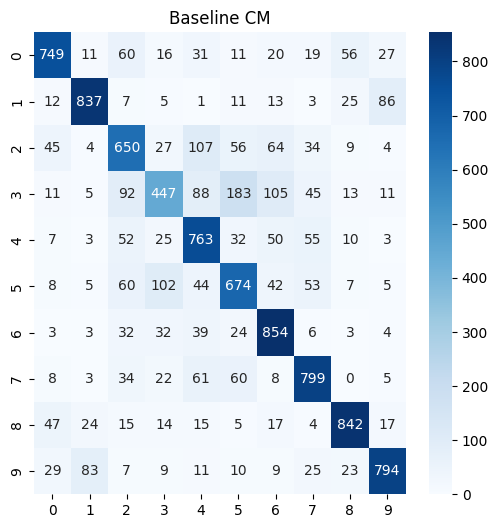

In [29]:
plot_confusion_matrix(metrics_base["confusion_matrix"], title="Baseline CM")

###Gaussian NB

In [30]:
cnn = basemodel.backbone

for param in cnn.parameters():
    param.requires_grad = False

cnn.eval()

FeatureCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

In [31]:
X_train_on_base, y_train_on_base = extract_features(cnn, train_loader, device)
X_test_on_base, y_test_on_base = extract_features(cnn, test_loader, device)
X_svhn_on_base, y_svhn_on_base = extract_features(cnn, svhn_loader, device)

In [32]:
nb = GaussianNB()
nb.fit(X_train_on_base.numpy(), y_train_on_base.numpy())

GaussianNB()

In [33]:
metrics_nb = classification_metrics(
    y_test_on_base.numpy(),
    nb.predict(X_test_on_base)
)

print(metrics_nb["report"])

              precision    recall  f1-score   support

           0       0.62      0.60      0.61      1000
           1       0.71      0.69      0.70      1000
           2       0.53      0.32      0.40      1000
           3       0.43      0.35      0.39      1000
           4       0.45      0.61      0.52      1000
           5       0.54      0.52      0.53      1000
           6       0.58      0.73      0.65      1000
           7       0.70      0.59      0.64      1000
           8       0.64      0.73      0.68      1000
           9       0.66      0.70      0.68      1000

    accuracy                           0.58     10000
   macro avg       0.59      0.58      0.58     10000
weighted avg       0.59      0.58      0.58     10000



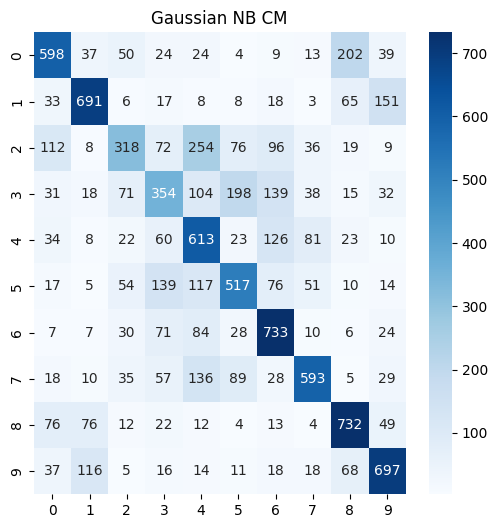

In [34]:
plot_confusion_matrix(metrics_nb["confusion_matrix"], title="Gaussian NB CM")

###Bayesian

In [35]:
class BayesianCNN(nn.Module):

    def __init__(
        self,
        num_classes=10,
        embedding_dim=128
    ):
        super().__init__()

        self.num_classes = num_classes

        self.backbone = FeatureCNN()

        self.embedding = nn.Linear(
            128 * 4 * 4,
            embedding_dim
        )

        self.head = nn.Identity()

        self.register_buffer(
            "class_count",
            torch.zeros(num_classes)
        )

        self.register_buffer(
            "class_mean",
            torch.zeros(
                num_classes,
                embedding_dim
            )
        )

        self.register_buffer(
            "class_var",
            torch.ones(
                num_classes,
                embedding_dim
            )
        )

        self.eps = 1e-6

    def extract_embedding(self, x):

        feats = self.backbone(x)

        return self.embedding(feats)

    def forward(self, x):

        z = self.extract_embedding(x)

        means = self.class_mean.unsqueeze(0)
        vars_ = self.class_var.unsqueeze(0)

        diff = z.unsqueeze(1) - means

        log_likelihood = -0.5 * (
            (diff ** 2 / vars_).sum(dim=2)
            +
            torch.log(vars_).sum(dim=2)
        )

        prior = (
            self.class_count + self.eps
        )

        prior = prior / prior.sum()

        log_prior = torch.log(prior)

        logits = (
            log_likelihood
            +
            log_prior.unsqueeze(0)
        )

        return logits

    @torch.no_grad()
    def update_statistics(
        self,
        embeddings,
        labels
    ):

        for c in range(self.num_classes):

            mask = labels == c

            if mask.sum() == 0:
                continue

            z = embeddings[mask]

            batch_count = z.size(0)

            batch_mean = z.mean(dim=0)

            batch_var = z.var(
                dim=0,
                unbiased=False
            )

            old_count = self.class_count[c]

            new_count = (
                old_count
                +
                batch_count
            )

            if old_count.item() == 0:

                self.class_mean[c] = batch_mean

                self.class_var[c] = (
                    batch_var
                    +
                    self.eps
                )

            else:

                old_mean = self.class_mean[c]

                old_var = self.class_var[c]

                delta = (
                    batch_mean
                    -
                    old_mean
                )

                new_mean = (
                    old_count * old_mean
                    +
                    batch_count * batch_mean
                ) / new_count

                new_var = (
                    old_count * (
                        old_var
                        +
                        (old_mean - new_mean) ** 2
                    )
                    +
                    batch_count * (
                        batch_var
                        +
                        (batch_mean - new_mean) ** 2
                    )
                ) / new_count

                self.class_mean[c] = new_mean

                self.class_var[c] = (
                    new_var
                    +
                    self.eps
                )

            self.class_count[c] = new_count


In [36]:
bayes_model = BayesianCNN(
    num_classes=10,
    embedding_dim=128
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(bayes_model.backbone.parameters())
    +
    list(bayes_model.embedding.parameters()),
    lr=1e-3
)


fit(
    model=bayes_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=False
)

results_bayes = evaluate_model(
    bayes_model,
    test_loader,
    device
)

metrics_bayes = classification_metrics(
    results_bayes["labels"].numpy(),
    results_bayes["preds"].numpy()
)

print(metrics_bayes["report"])

100%|██████████| 782/782 [00:18<00:00, 41.88it/s, acc=0.264, loss=1.46]


Epoch 1/10 | loss=3.6180 | acc=0.2640


100%|██████████| 782/782 [00:19<00:00, 41.02it/s, acc=0.462, loss=1.04]


Epoch 2/10 | loss=1.4599 | acc=0.4620


100%|██████████| 782/782 [00:18<00:00, 41.87it/s, acc=0.535, loss=1.38]


...

Epoch 8/10 | loss=0.9105 | acc=0.6863


100%|██████████| 782/782 [00:18<00:00, 41.71it/s, acc=0.701, loss=0.527]


Epoch 9/10 | loss=0.8632 | acc=0.7011


100%|██████████| 782/782 [00:19<00:00, 40.97it/s, acc=0.718, loss=0.538]


Epoch 10/10 | loss=0.8078 | acc=0.7177
              precision    recall  f1-score   support

           0       0.64      0.73      0.68      1000
           1       0.94      0.68      0.79      1000
           2       0.57      0.57      0.57      1000
           3       0.48      0.56      0.52      1000
           4       0.52      0.76      0.62      1000
           5       0.76      0.43      0.55      1000
           6       0.88      0.58      0.70      1000
           7       0.72      0.77      0.74      1000
           8       0.64      0.90      0.75      1000
           9       0.86      0.69      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.70      0.67      0.67     10000
weighted avg       0.70      0.67      0.67     10000



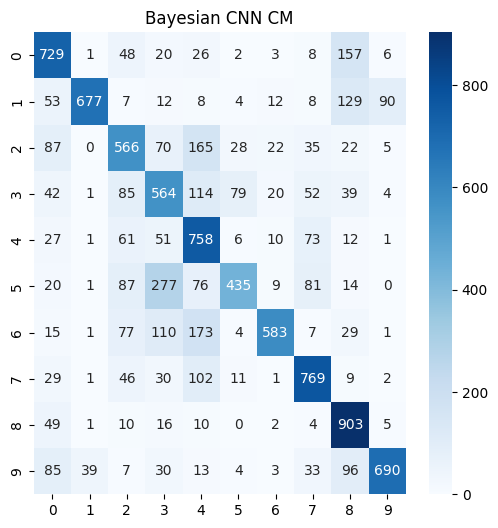

In [37]:
plot_confusion_matrix(
    metrics_bayes["confusion_matrix"],
    title="Bayesian CNN CM"
)

##EVALUATION

###Baseline

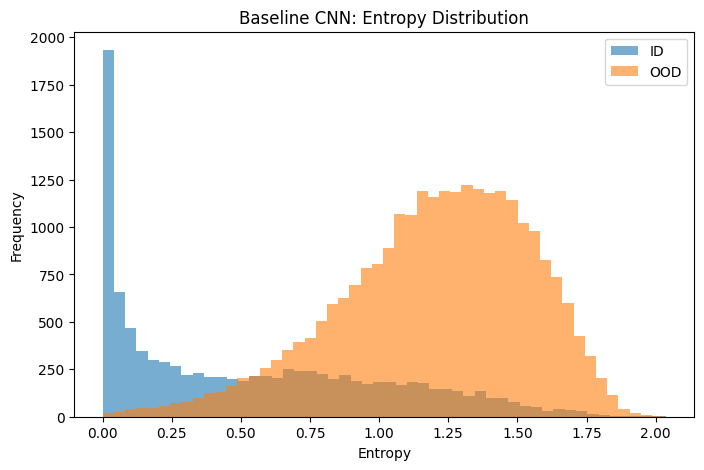

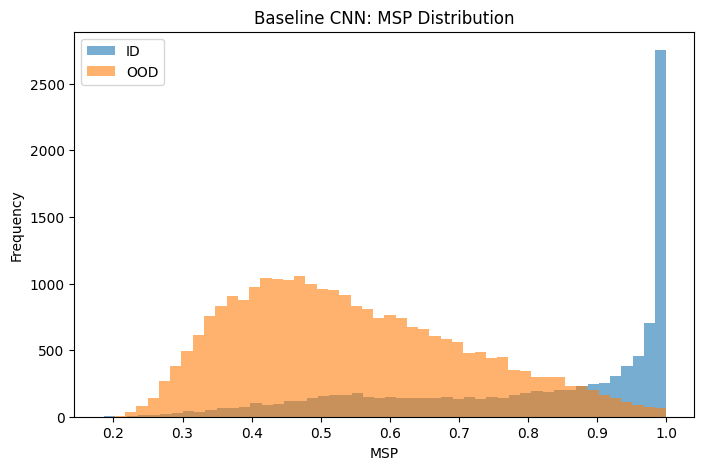

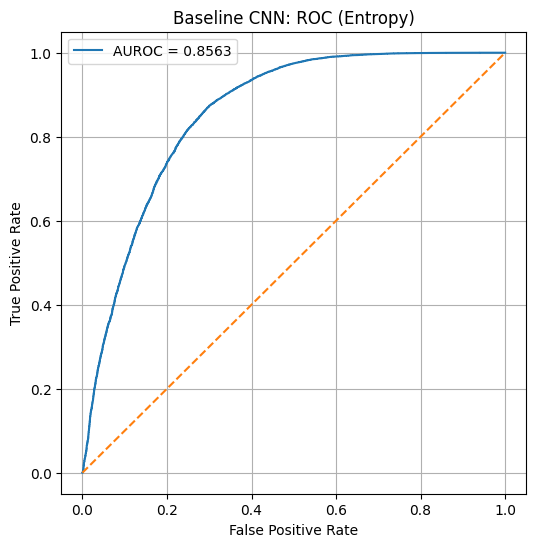

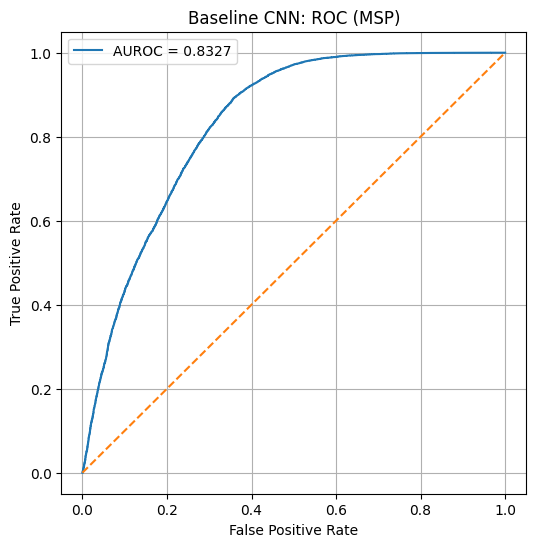

Baseline CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8563
MSP AUROC: 0.8327


In [38]:
basemodel_id_results = evaluate_model(
    model=basemodel,
    loader=test_loader,
    device=device
)

basemodel_ood_results = evaluate_model(
    model=basemodel,
    loader=svhn_loader,
    device=device
)
baseline_metrics = evaluate_ood(
    id_probs=basemodel_id_results["probs"],
    ood_probs=basemodel_ood_results["probs"],
    model_name="Baseline CNN"
)

Baseline CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 11333.51it/s]


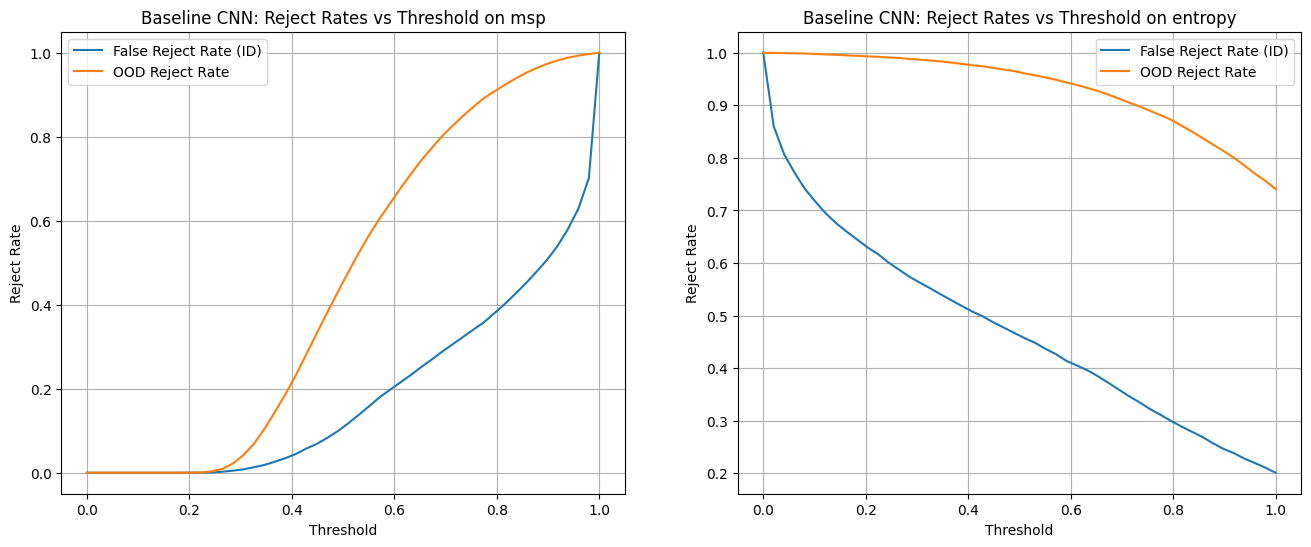

In [39]:
plot_reject_curves(
    id_probs=basemodel_id_results["probs"],
    ood_probs=basemodel_ood_results["probs"],
    model_name="Baseline CNN"
)

###Gaussian NB

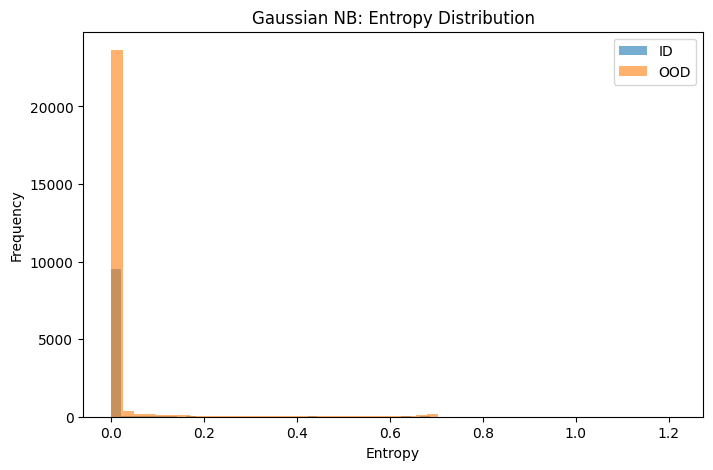

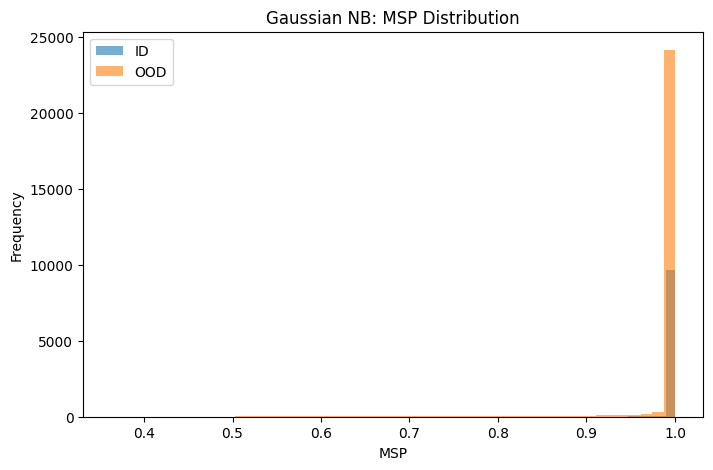

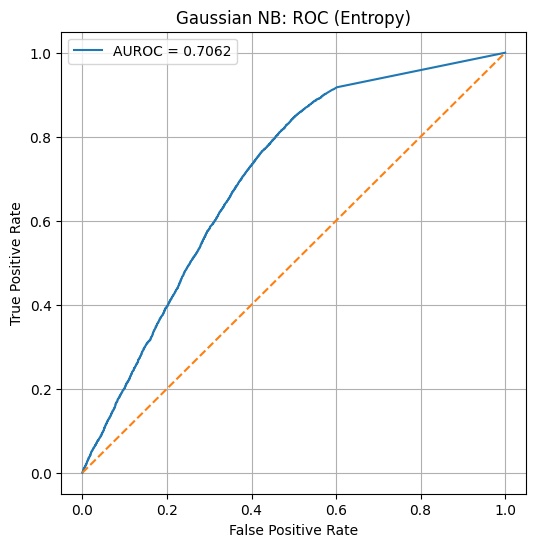

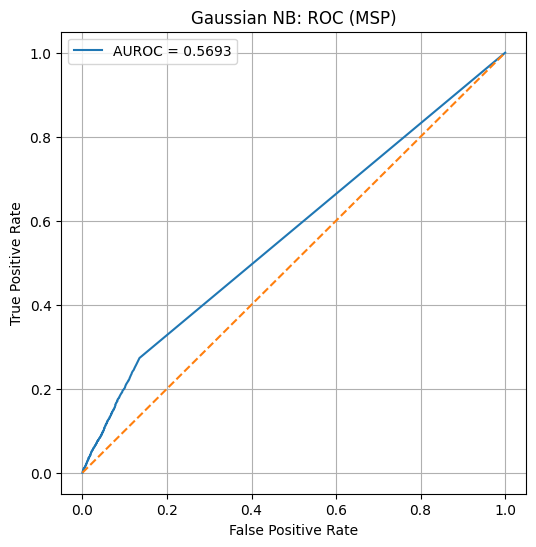

Gaussian NB OOD Metrics
----------------------------------------
Entropy AUROC: 0.7062
MSP AUROC: 0.5693


In [40]:
nb_probs_id = torch.tensor(
    nb.predict_proba(X_test_on_base.numpy())
).float()

nb_probs_ood = torch.tensor(
    nb.predict_proba(X_svhn_on_base.numpy())
).float()

nb_metrics = evaluate_ood(
    id_probs=nb_probs_id,
    ood_probs=nb_probs_ood,
    model_name="Gaussian NB"
)

Gaussian NB reject curves: 100%|██████████| 50/50 [00:00<00:00, 11913.61it/s]


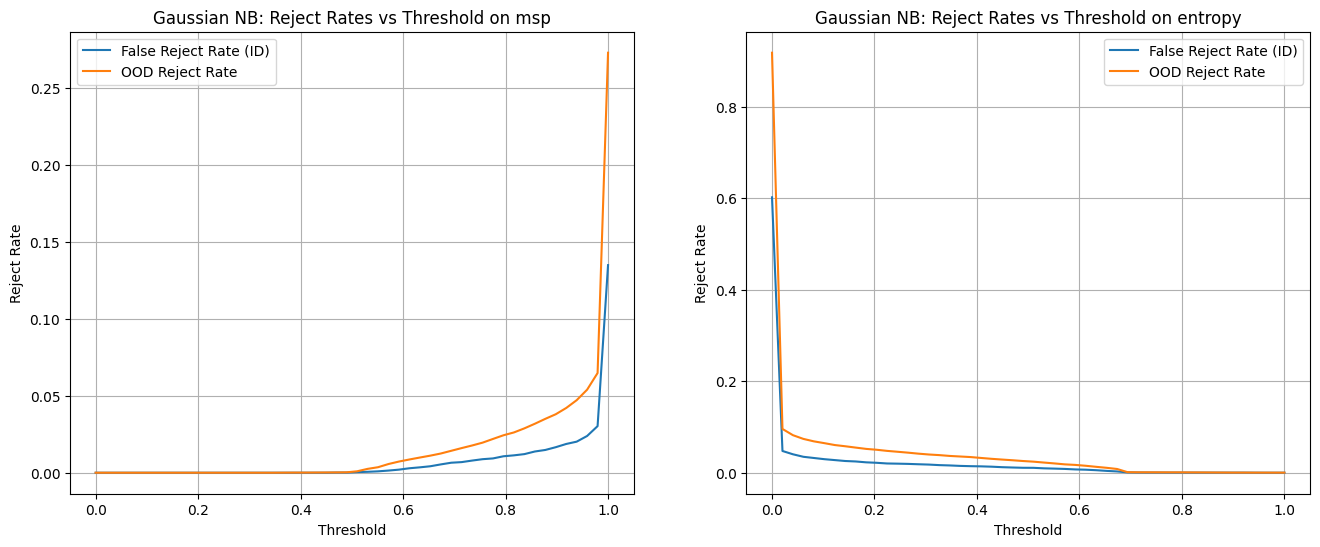

In [41]:
plot_reject_curves(
    id_probs=nb_probs_id,
    ood_probs=nb_probs_ood,
    model_name="Gaussian NB"
)

###Bayesian

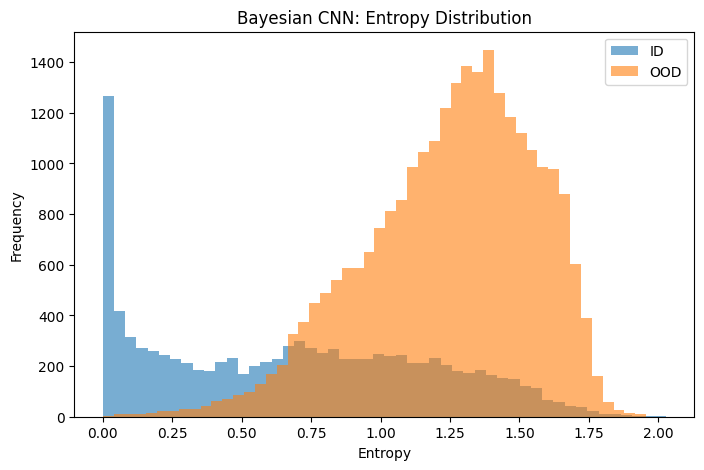

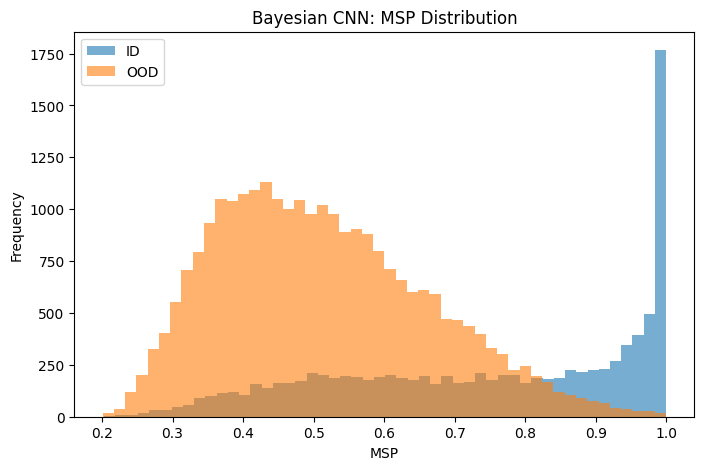

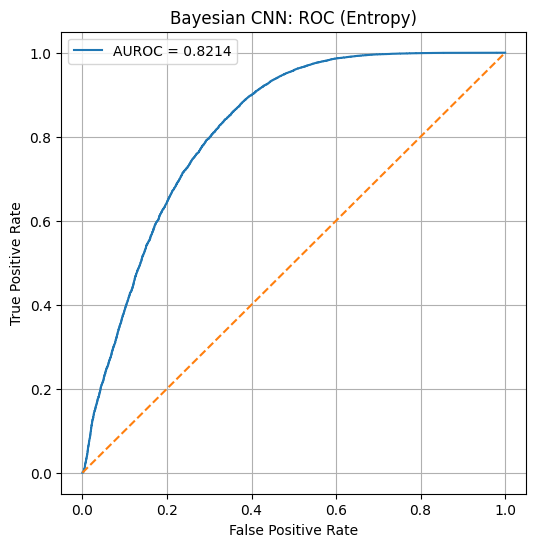

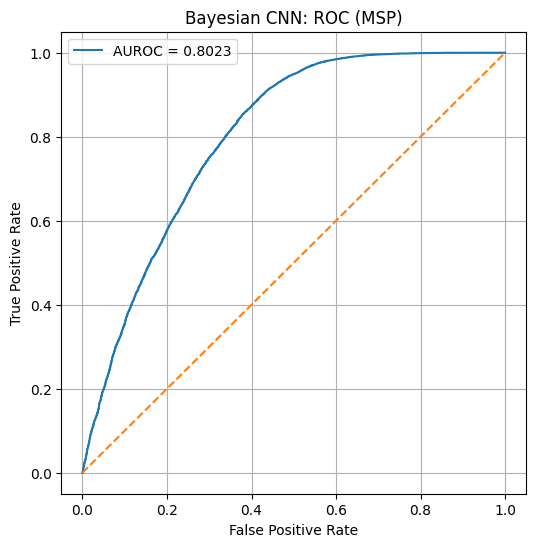

Bayesian CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8214
MSP AUROC: 0.8023


In [42]:
bayes_id_results = evaluate_model(
    model=bayes_model,
    loader=test_loader,
    device=device
)

bayes_ood_results = evaluate_model(
    model=bayes_model,
    loader=svhn_loader,
    device=device
)
bayes_metrics = evaluate_ood(
    id_probs=bayes_id_results["probs"],
    ood_probs=bayes_ood_results["probs"],
    model_name="Bayesian CNN"
)

Bayesian CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 11498.80it/s]


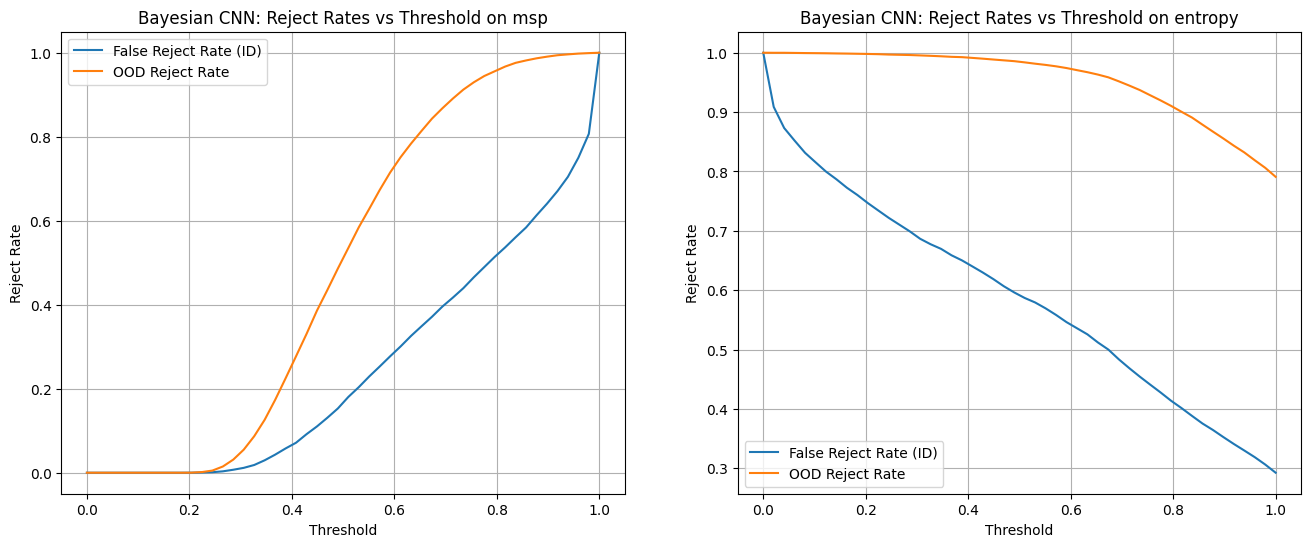

In [43]:
plot_reject_curves(
    id_probs=bayes_id_results["probs"],
    ood_probs=bayes_ood_results["probs"],
    model_name="Bayesian CNN"
)

# MODEL WITH OOD CLASS

In [44]:
ood_ratio = 1.0

##MODELS

###Baseline with OOD

In [45]:
basemodel_OOD = CNN_SOFTMAX(num_classes=11).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    basemodel_OOD.parameters(),
    lr=1e-3
    )

fit(
    model=basemodel_OOD,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=True,
    ood_ratio = ood_ratio
)

results_base_ood = evaluate_model(
    basemodel_OOD,
    test_loader,
    device,
    ood_class = True
)

metrics_base_ood = classification_metrics(
    results_base_ood["labels"].numpy(),
    results_base_ood["preds"].numpy()
)

print(metrics_base_ood["report"])

100%|██████████| 782/782 [00:14<00:00, 52.44it/s, acc=0.0554, loss=0.901]


Epoch 1/10 | loss=0.8174 | acc=0.0554


100%|██████████| 782/782 [00:14<00:00, 54.07it/s, acc=0.0376, loss=0.536]


Epoch 2/10 | loss=0.5989 | acc=0.0376


100%|██████████| 782/782 [00:14<00:00, 52.97it/s, acc=0.0306, loss=0.334]


...

Epoch 8/10 | loss=0.3172 | acc=0.0208


100%|██████████| 782/782 [00:14<00:00, 52.33it/s, acc=0.0192, loss=0.431]


Epoch 9/10 | loss=0.2968 | acc=0.0192


100%|██████████| 782/782 [00:15<00:00, 50.71it/s, acc=0.0183, loss=0.3]


Epoch 10/10 | loss=0.2752 | acc=0.0183
              precision    recall  f1-score   support

           1       0.76      0.80      0.78      1000
           2       0.83      0.87      0.85      1000
           3       0.63      0.69      0.66      1000
           4       0.57      0.60      0.58      1000
           5       0.73      0.61      0.67      1000
           6       0.70      0.63      0.67      1000
           7       0.79      0.82      0.81      1000
           8       0.80      0.77      0.79      1000
           9       0.82      0.88      0.85      1000
          10       0.85      0.79      0.82      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



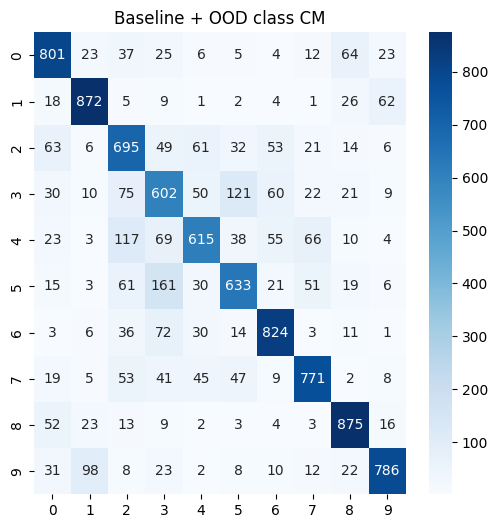

In [46]:
plot_confusion_matrix(metrics_base_ood["confusion_matrix"], title="Baseline + OOD class CM")

###Gaussian NB with OOD

In [47]:
cnn_OOD = basemodel_OOD.backbone

for param in cnn_OOD.parameters():
    param.requires_grad = False

cnn_OOD.eval()

FeatureCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

In [48]:
X_test_on_OOD, y_test_on_OOD = extract_features(cnn_OOD, test_loader, device)
X_svhn_on_OOD, y_svhn_on_OOD = extract_features(cnn_OOD, svhn_loader, device)

In [49]:
X_train_on_OOD, y_train_on_OOD = extract_features(cnn_OOD, train_loader, device)

ood_batch = int(X_train_on_OOD.size(0) * ood_ratio)

x_ood = sample_uniform_ood(ood_batch, device)

X_ood = cnn_OOD(x_ood).cpu()
y_ood = torch.zeros(ood_batch, dtype=torch.long)

X_train_on_OOD = torch.cat([X_train_on_OOD, X_ood])
y_train_on_OOD = torch.cat([shift_labels(y_train_on_OOD), y_ood])

In [50]:
nb_OOD = GaussianNB()
nb_OOD.fit(X_train_on_OOD.numpy(), y_train_on_OOD.numpy())

GaussianNB()

In [51]:
metrics_nb_ood = classification_metrics(
    shift_labels(y_test_on_OOD).numpy(),
    nb_OOD.predict(X_test_on_OOD)
)

print(metrics_nb_ood["report"])

              precision    recall  f1-score   support

           1       0.62      0.48      0.54      1000
           2       0.66      0.70      0.68      1000
           3       0.52      0.25      0.34      1000
           4       0.45      0.30      0.36      1000
           5       0.41      0.61      0.49      1000
           6       0.53      0.50      0.52      1000
           7       0.58      0.72      0.64      1000
           8       0.67      0.57      0.62      1000
           9       0.51      0.78      0.62      1000
          10       0.66      0.65      0.66      1000

    accuracy                           0.56     10000
   macro avg       0.56      0.56      0.54     10000
weighted avg       0.56      0.56      0.54     10000



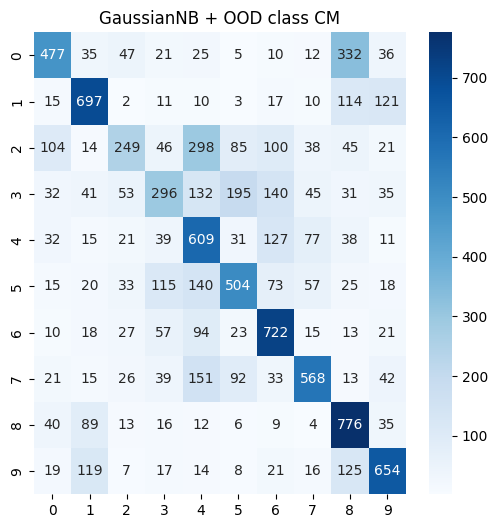

In [52]:
plot_confusion_matrix(metrics_nb_ood["confusion_matrix"], title="GaussianNB + OOD class CM")

###Bayesian with OOD

In [53]:
bayes_OOD = BayesianCNN(
    num_classes=11
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(bayes_OOD.backbone.parameters())
    +
    list(bayes_OOD.embedding.parameters()),
    lr=1e-3
)

fit(
    model=bayes_OOD,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="softmax",
    use_ood=True,
    ood_ratio=1.0
)

results_bayes_ood = evaluate_model(
    bayes_OOD,
    test_loader,
    device,
    ood_class = True
)

metrics_bayes_ood = classification_metrics(
    results_bayes_ood["labels"].numpy(),
    results_bayes_ood["preds"].numpy()
)

print(metrics_bayes_ood["report"])

100%|██████████| 782/782 [00:21<00:00, 36.74it/s, acc=0.0644, loss=0.943]


Epoch 1/10 | loss=1.2674 | acc=0.0644


100%|██████████| 782/782 [00:21<00:00, 36.63it/s, acc=0.0412, loss=0.516]


Epoch 2/10 | loss=0.6824 | acc=0.0412


100%|██████████| 782/782 [00:20<00:00, 38.09it/s, acc=0.0363, loss=0.878]


...

100%|██████████| 782/782 [00:20<00:00, 37.87it/s, acc=0.0256, loss=0.392]


Epoch 9/10 | loss=0.3915 | acc=0.0256


100%|██████████| 782/782 [00:21<00:00, 36.27it/s, acc=0.0227, loss=0.205]


Epoch 10/10 | loss=0.3714 | acc=0.0227
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.70      0.76      0.73      1000
           2       0.91      0.70      0.79      1000
           3       0.54      0.63      0.58      1000
           4       0.47      0.51      0.49      1000
           5       0.63      0.67      0.65      1000
           6       0.56      0.68      0.61      1000
           7       0.84      0.70      0.76      1000
           8       0.72      0.75      0.74      1000
           9       0.85      0.74      0.79      1000
          10       0.81      0.70      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.64      0.62      0.63     10000
weighted avg       0.70      0.68      0.69     10000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


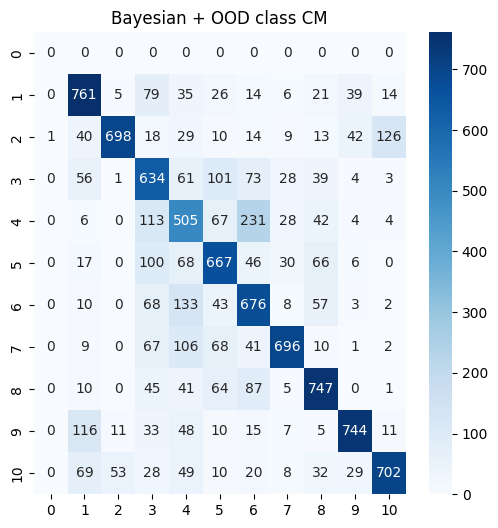

In [54]:
plot_confusion_matrix(metrics_bayes_ood["confusion_matrix"], title="Bayesian + OOD class CM")

##EVALUATION

###Baseline with OOD

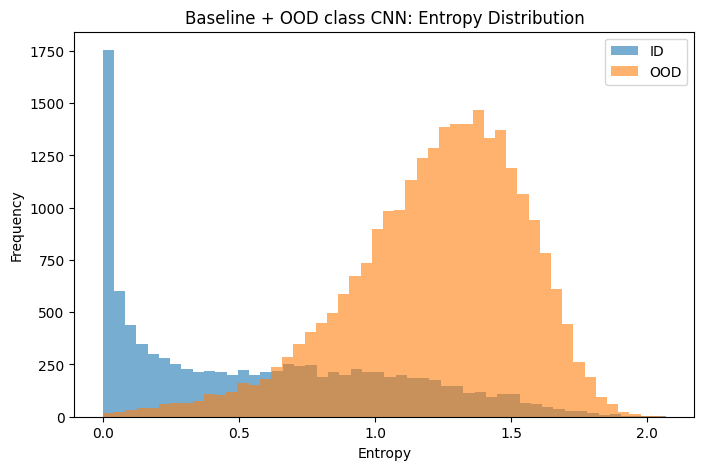

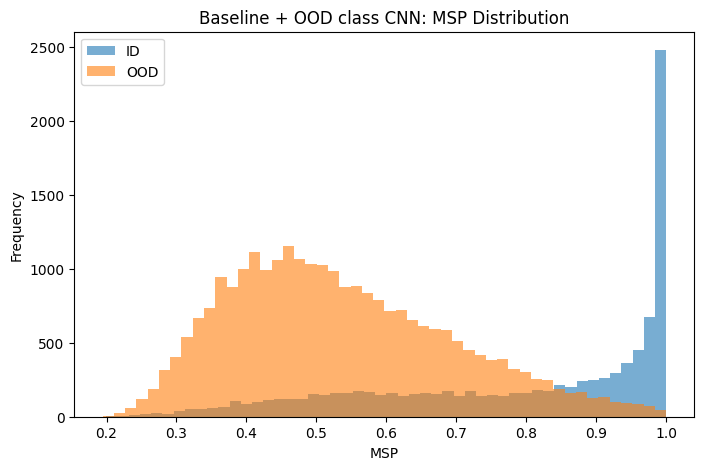

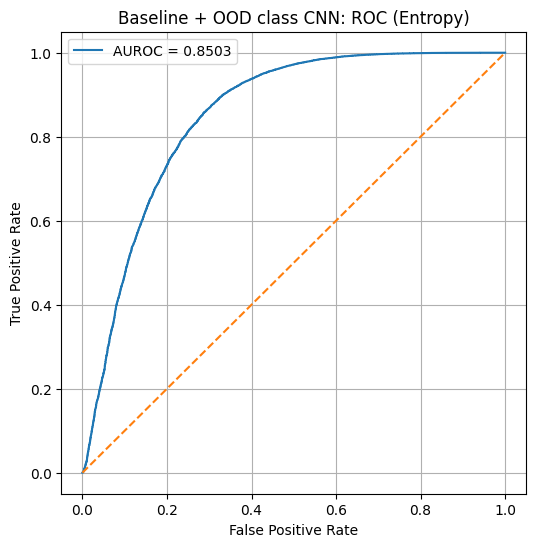

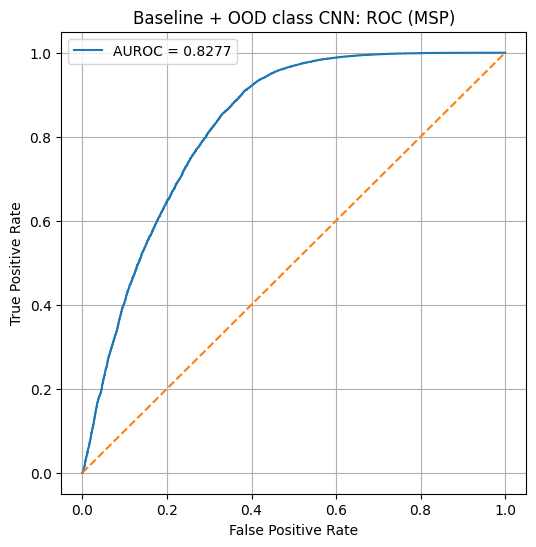

Baseline + OOD class CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8503
MSP AUROC: 0.8277


In [55]:
basemodel_with_ood_id_results = evaluate_model(
    model=basemodel_OOD,
    loader=test_loader,
    device=device
)

basemodel_with_ood_ood_results = evaluate_model(
    model=basemodel_OOD,
    loader=svhn_loader,
    device=device
)
baseline_with_ood_metrics = evaluate_ood(
    id_probs=basemodel_with_ood_id_results["probs"],
    ood_probs=basemodel_with_ood_ood_results["probs"],
    model_name="Baseline + OOD class CNN"
)

Baseline + OOD class reject curves: 100%|██████████| 50/50 [00:00<00:00, 11249.00it/s]


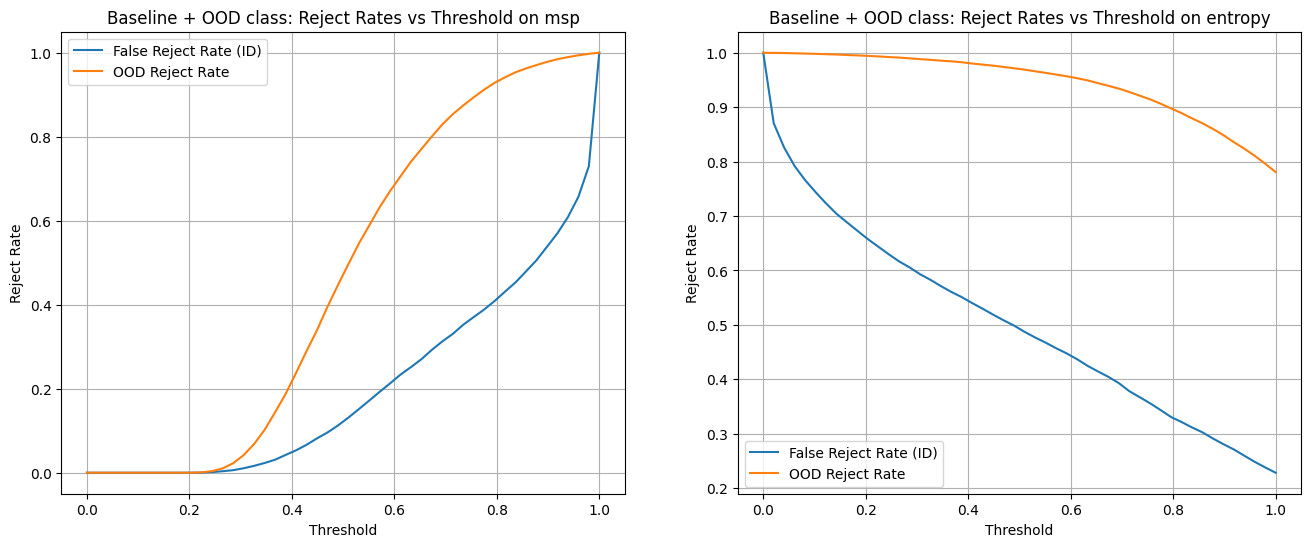

In [56]:
plot_reject_curves(
    id_probs=basemodel_with_ood_id_results["probs"],
    ood_probs=basemodel_with_ood_ood_results["probs"],
    model_name="Baseline + OOD class"
)

## Realistic auxiliary OOD training: CIFAR-100


In [57]:
def train_epoch_with_ood_loader(
    model,
    id_loader,
    ood_loader,
    criterion,
    optimizer,
    device,
    ood_ratio=0.25
):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    ood_iter = iter(ood_loader)

    for x_id, y_id in tqdm(id_loader):
        try:
            x_ood, _ = next(ood_iter)
        except StopIteration:
            ood_iter = iter(ood_loader)
            x_ood, _ = next(ood_iter)

        x_id = x_id.to(device)
        y_id = y_id.to(device)
        x_ood = x_ood.to(device)

        ood_batch_size = max(
            1,
            min(
                x_ood.size(0),
                int(x_id.size(0) * ood_ratio)
            )
        )
        x_ood = x_ood[:ood_batch_size]

        y_id_targets = shift_labels(y_id)
        y_ood_targets = torch.zeros(
            ood_batch_size,
            dtype=torch.long,
            device=device
        )

        x = torch.cat([x_id, x_ood], dim=0)
        y = torch.cat([y_id_targets, y_ood_targets], dim=0)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        probs_id = torch.softmax(logits[:x_id.size(0)], dim=1)
        preds_id = probs_id.argmax(dim=1)

        correct += (preds_id == y_id).sum().item()
        total += y_id.size(0)
        total_loss += loss.item()

    return {
        "loss": total_loss / len(id_loader),
        "acc": correct / total
    }


def fit_with_ood_loader(
    model,
    id_loader,
    ood_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    ood_ratio=0.25
):
    history = []

    for epoch in range(epochs):
        metrics = train_epoch_with_ood_loader(
            model=model,
            id_loader=id_loader,
            ood_loader=ood_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            ood_ratio=ood_ratio
        )

        history.append(metrics)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"loss={metrics['loss']:.4f} | "
            f"acc={metrics['acc']:.4f}"
        )

    return history

In [58]:
basemodel_OOD_CIFAR100 = CNN_SOFTMAX(
    num_classes=11
).to(device)

criterion_cifar100_ood = nn.CrossEntropyLoss()

optimizer_cifar100_ood = torch.optim.Adam(
    basemodel_OOD_CIFAR100.parameters(),
    lr=1e-3
)

history_base_ood_cifar100 = fit_with_ood_loader(
    model=basemodel_OOD_CIFAR100,
    id_loader=train_loader,
    ood_loader=cifar100_train_loader,
    criterion=criterion_cifar100_ood,
    optimizer=optimizer_cifar100_ood,
    device=device,
    epochs=10,
    ood_ratio=0.25
)

100%|██████████| 782/782 [00:19<00:00, 40.94it/s]


Epoch 1/10 | loss=1.6621 | acc=0.0501


100%|██████████| 782/782 [00:19<00:00, 39.90it/s]


Epoch 2/10 | loss=1.3084 | acc=0.0366


100%|██████████| 782/782 [00:19<00:00, 40.74it/s]


...

Epoch 8/10 | loss=0.8271 | acc=0.0220


100%|██████████| 782/782 [00:19<00:00, 39.23it/s]


Epoch 9/10 | loss=0.7843 | acc=0.0227


100%|██████████| 782/782 [00:19<00:00, 40.79it/s]

Epoch 10/10 | loss=0.7461 | acc=0.0200


In [59]:
def evaluate_ood_class_model(model, ood_loader, name):
    id_results = evaluate_model(
        model, test_loader, device, mode="softmax"
    )
    ood_results = evaluate_model(
        model, ood_loader, device, mode="softmax"
    )

    metrics = compute_ood_metrics(
        id_results["probs"],
        ood_results["probs"]
    )

    return {
        "Model": name,
        "MSP AUROC": metrics["msp"]["auroc"],
        "Entropy AUROC": metrics["entropy"]["auroc"]
    }


auxiliary_ood_results = pd.DataFrame([
    evaluate_ood_class_model(
        basemodel_OOD_CIFAR100,
        svhn_loader,
        "Baseline + CIFAR-100 OOD training / SVHN"
    ),
    evaluate_ood_class_model(
        basemodel_OOD_CIFAR100,
        cifar100_test_loader,
        "Baseline + CIFAR-100 OOD training / CIFAR-100"
    )
])

display(auxiliary_ood_results)

,Model,MSP AUROC,Entropy AUROC
0,Baseline + CIFAR-100 OOD training / SVHN,0.591452,0.616904
1,Baseline + CIFAR-100 OOD training / CIFAR-100,0.606169,0.614584


###Gaussian NB with OOD

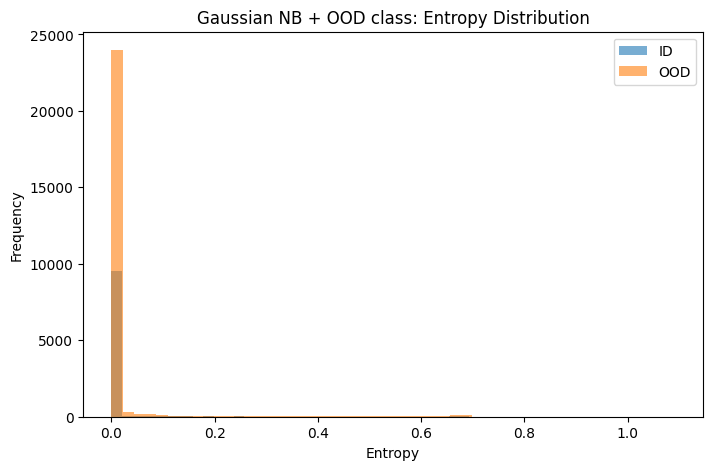

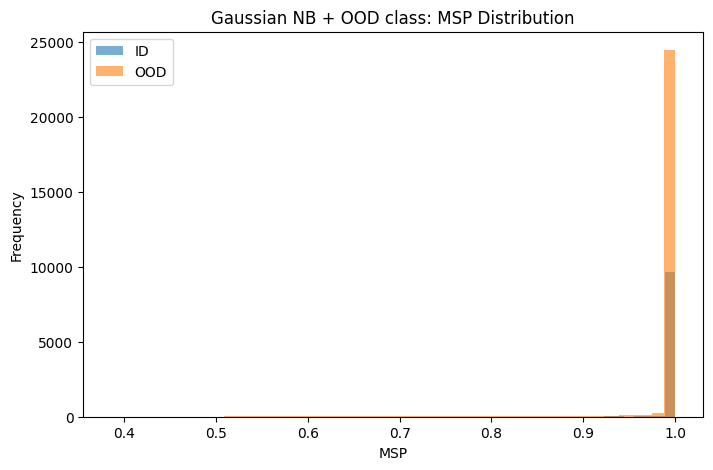

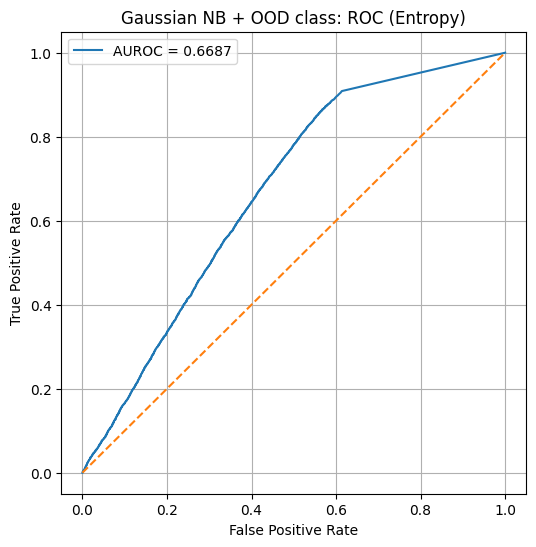

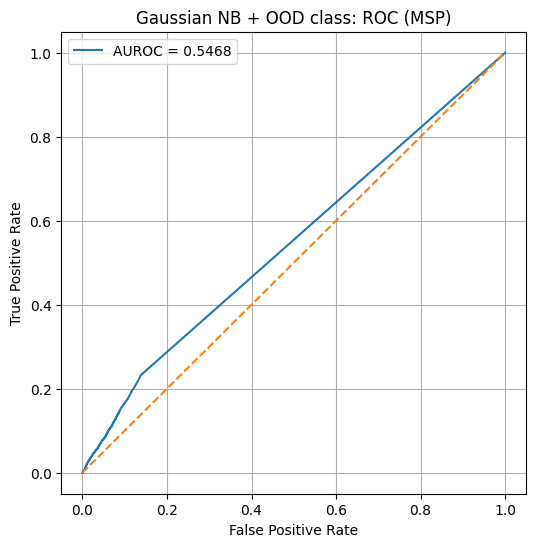

Gaussian NB + OOD class OOD Metrics
----------------------------------------
Entropy AUROC: 0.6687
MSP AUROC: 0.5468


In [60]:
nb_with_ood_probs_id = torch.tensor(
    nb_OOD.predict_proba(X_test_on_OOD.numpy())
).float()

nb_with_ood_probs_ood = torch.tensor(
    nb_OOD.predict_proba(X_svhn_on_OOD.numpy())
).float()

nb_with_ood_metrics = evaluate_ood(
    id_probs=nb_with_ood_probs_id,
    ood_probs=nb_with_ood_probs_ood,
    model_name="Gaussian NB + OOD class"
)

Gaussian NB + OOD class reject curves: 100%|██████████| 50/50 [00:00<00:00, 7608.30it/s]


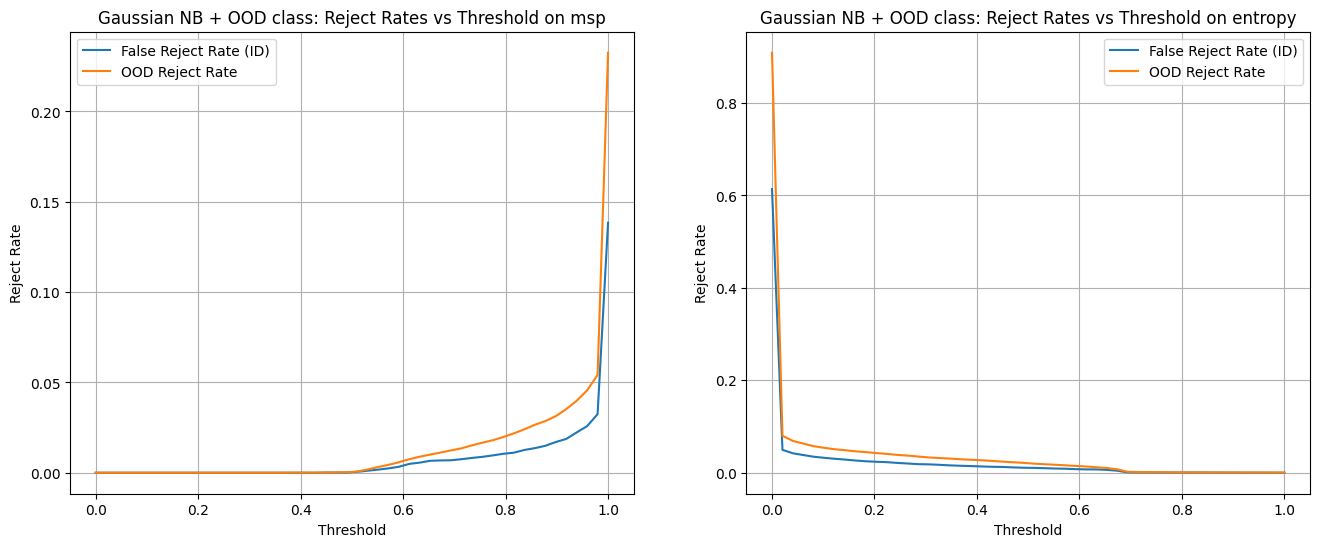

In [61]:
plot_reject_curves(
    id_probs=nb_with_ood_probs_id,
    ood_probs=nb_with_ood_probs_ood,
    model_name="Gaussian NB + OOD class"
)

###Bayesian with OOD

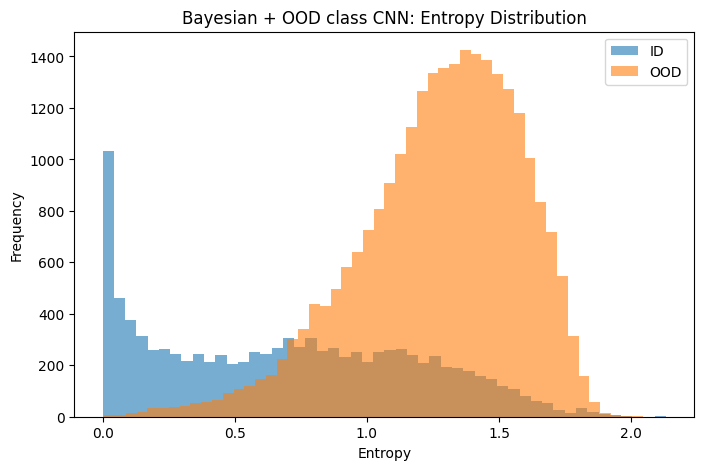

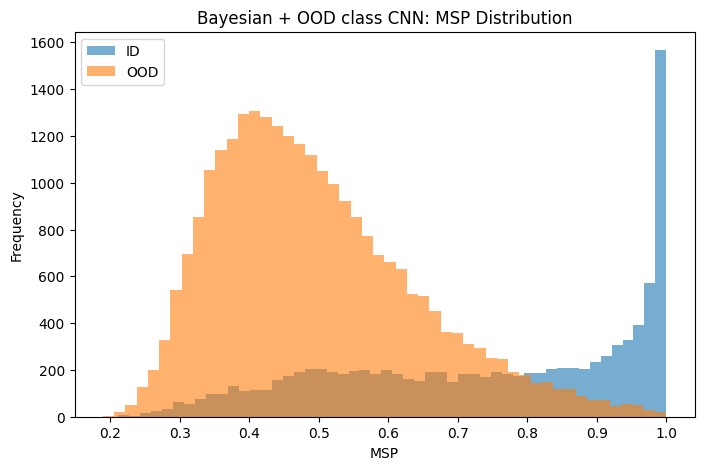

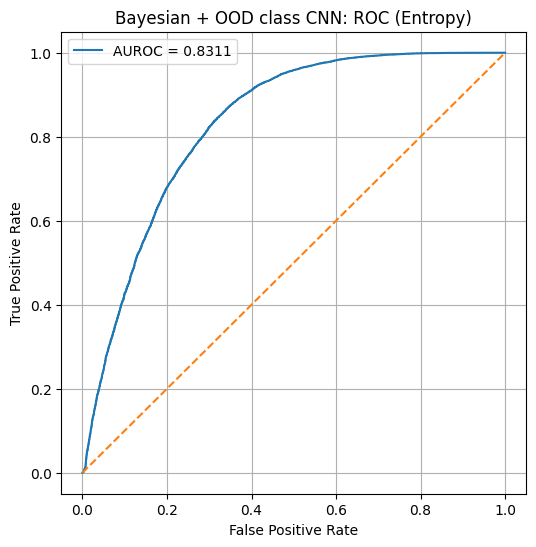

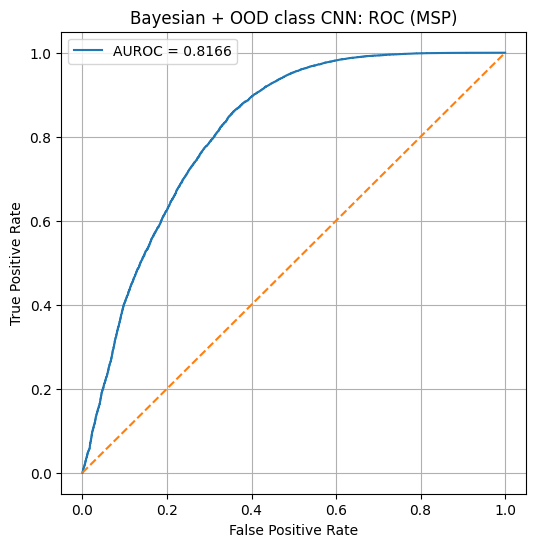

Bayesian + OOD class CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8311
MSP AUROC: 0.8166


In [62]:
bayes_with_ood_id_results = evaluate_model(
    model=bayes_OOD,
    loader=test_loader,
    device=device
)

bayes_with_ood_ood_results = evaluate_model(
    model=bayes_OOD,
    loader=svhn_loader,
    device=device
)
bayes_with_ood_metrics = evaluate_ood(
    id_probs=bayes_with_ood_id_results["probs"],
    ood_probs=bayes_with_ood_ood_results["probs"],
    model_name="Bayesian + OOD class CNN"
)

Baseline + OOD class reject curves: 100%|██████████| 50/50 [00:00<00:00, 9953.73it/s]


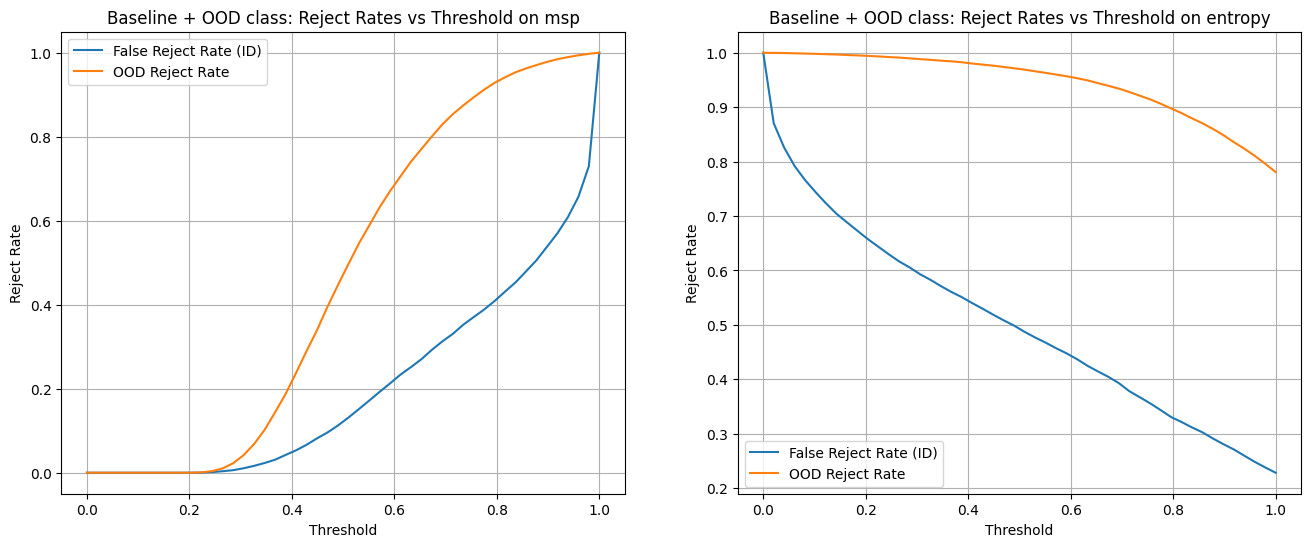

In [63]:
plot_reject_curves(
    id_probs=basemodel_with_ood_id_results["probs"],
    ood_probs=basemodel_with_ood_ood_results["probs"],
    model_name="Baseline + OOD class"
)

#UNARY CLASSIFICATION

In [64]:
class UnaryCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.backbone = FeatureCNN()

        self.head = nn.Linear(
            128 * 4 * 4,
            num_classes
        )

    def forward(self, x):

        feats = self.backbone(x)

        logits = self.head(feats)

        return logits

In [65]:
model_unary = UnaryCNN(num_classes=10).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary.parameters(),
    lr=1e-3
)

fit(
    model=model_unary,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=False
)

results_unary = evaluate_model(
    model_unary,
    test_loader,
    device
)

metrics_unary  = classification_metrics(
    results_unary["labels"].numpy(),
    results_unary["preds"].numpy()
)

print(metrics_unary["report"])


100%|██████████| 782/782 [00:13<00:00, 59.47it/s, acc=0.399, loss=0.238]


Epoch 1/10 | loss=0.2548 | acc=0.3991


100%|██████████| 782/782 [00:13<00:00, 58.60it/s, acc=0.581, loss=0.163]


Epoch 2/10 | loss=0.1958 | acc=0.5809


100%|██████████| 782/782 [00:13<00:00, 59.15it/s, acc=0.651, loss=0.152]


...

Epoch 8/10 | loss=0.1215 | acc=0.7760


100%|██████████| 782/782 [00:13<00:00, 58.08it/s, acc=0.791, loss=0.0862]


Epoch 9/10 | loss=0.1159 | acc=0.7910


100%|██████████| 782/782 [00:13<00:00, 58.08it/s, acc=0.803, loss=0.158]


Epoch 10/10 | loss=0.1107 | acc=0.8031
              precision    recall  f1-score   support

           0       0.76      0.79      0.78      1000
           1       0.82      0.89      0.85      1000
           2       0.70      0.55      0.62      1000
           3       0.54      0.58      0.56      1000
           4       0.69      0.67      0.68      1000
           5       0.57      0.70      0.63      1000
           6       0.84      0.76      0.80      1000
           7       0.76      0.81      0.78      1000
           8       0.86      0.83      0.85      1000
           9       0.87      0.77      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



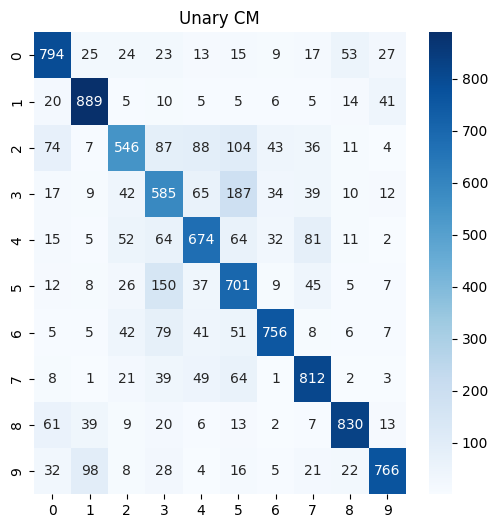

In [66]:
plot_confusion_matrix(metrics_unary["confusion_matrix"], title="Unary CM")

##EVALUATION

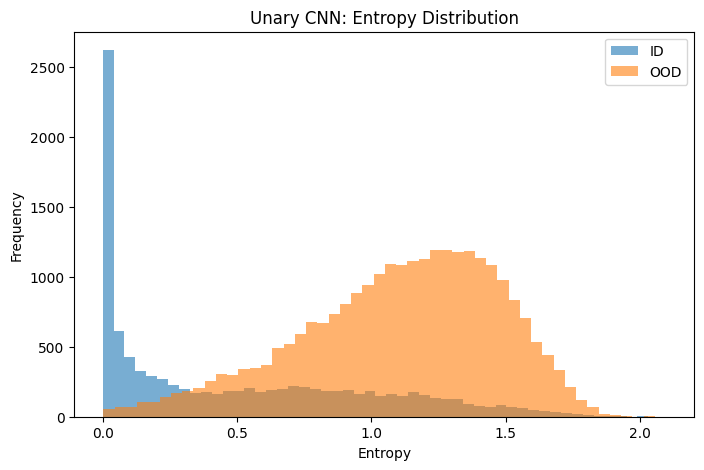

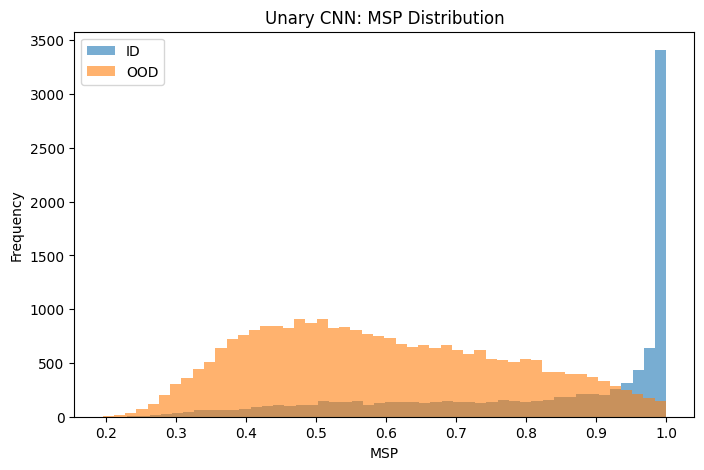

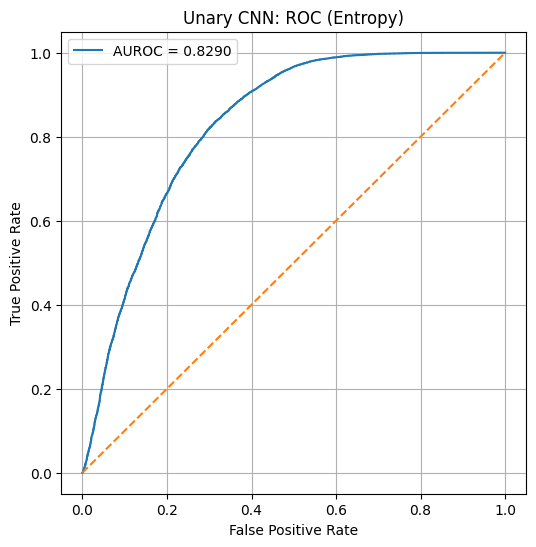

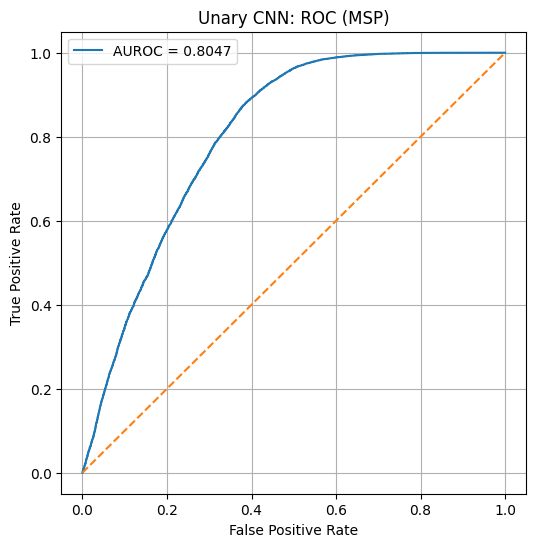

Unary CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8290
MSP AUROC: 0.8047


In [67]:
unary_id_results = evaluate_model(
    model=model_unary,
    loader=test_loader,
    device=device
)

unary_ood_results = evaluate_model(
    model=model_unary,
    loader=svhn_loader,
    device=device
)
unary_metrics = evaluate_ood(
    id_probs=unary_id_results["probs"],
    ood_probs=unary_ood_results["probs"],
    model_name="Unary CNN"
)

Unary CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 11177.06it/s]


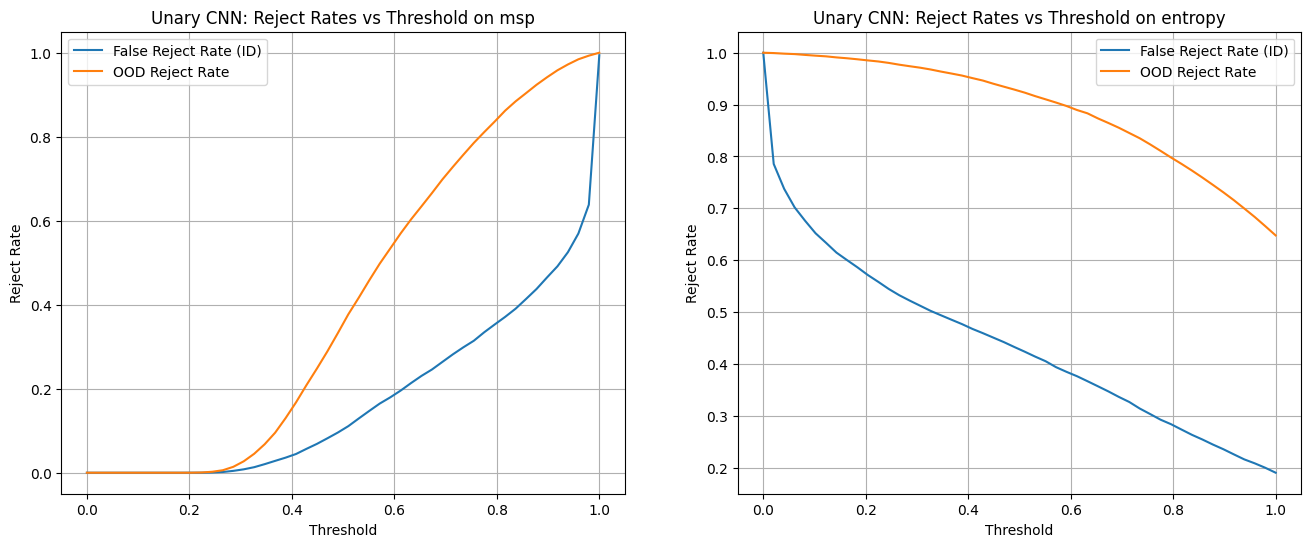

In [68]:
plot_reject_curves(
    id_probs=unary_id_results["probs"],
    ood_probs=unary_ood_results["probs"],
    model_name="Unary CNN"
)

##Train more epochs

In [69]:
steps, train_steps = 4, 10

fr_list_unary, orr_list_unary = progressive_training_evaluation(
    model_unary,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=True,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)




100%|██████████| 782/782 [00:14<00:00, 55.15it/s, acc=0.816, loss=0.103]


Epoch 1/10 | loss=0.0960 | acc=0.8164


100%|██████████| 782/782 [00:14<00:00, 54.98it/s, acc=0.824, loss=0.156]


Epoch 2/10 | loss=0.0930 | acc=0.8236


100%|██████████| 782/782 [00:13<00:00, 56.45it/s, acc=0.835, loss=0.0792]


...

Epoch 9/10 | loss=0.0242 | acc=0.9784


100%|██████████| 782/782 [00:14<00:00, 55.63it/s, acc=0.98, loss=0.0279]


Epoch 10/10 | loss=0.0239 | acc=0.9795


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 7062.31it/s]

step: 4/4: 
	FR = 0.19933000000000003
	ORR = 0.4625944990780577


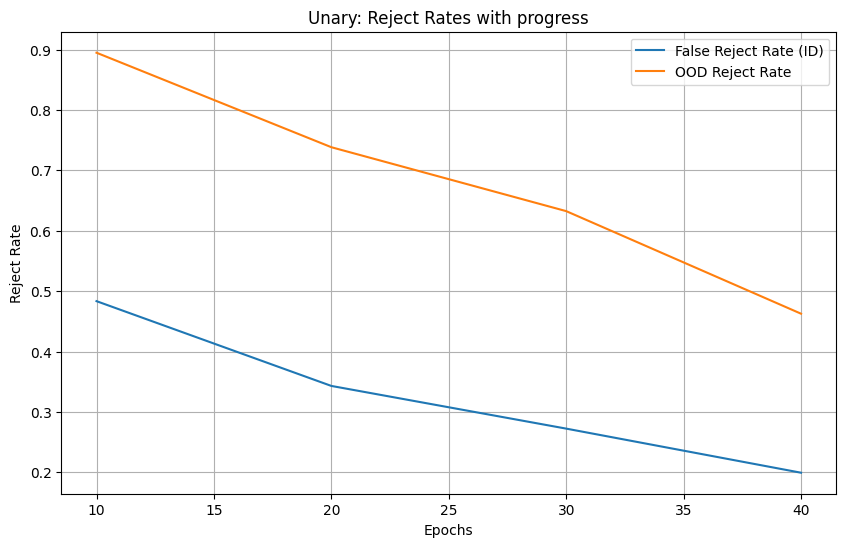

In [70]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary, orr_list_unary, model="Unary")

###Evaluation after additional epochs

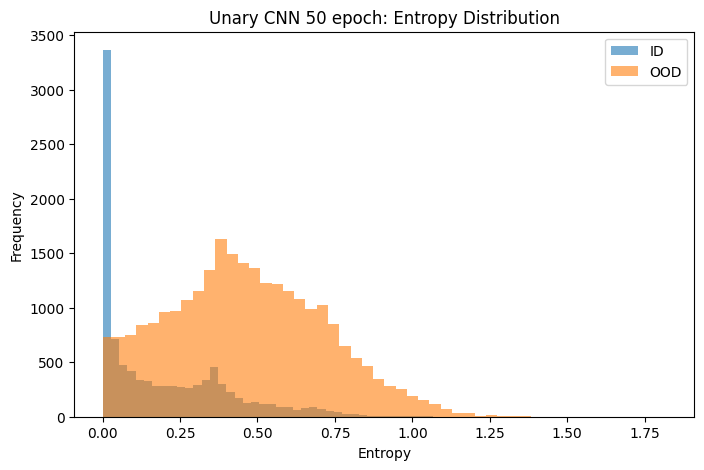

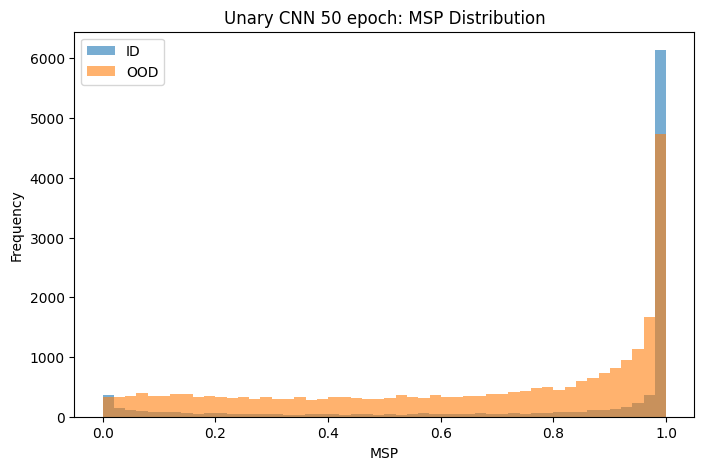

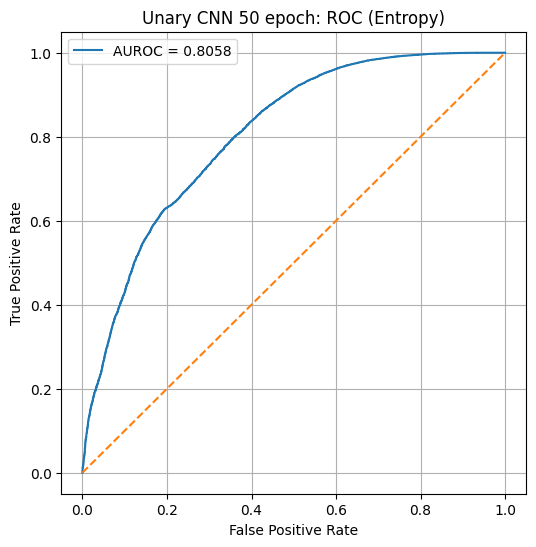

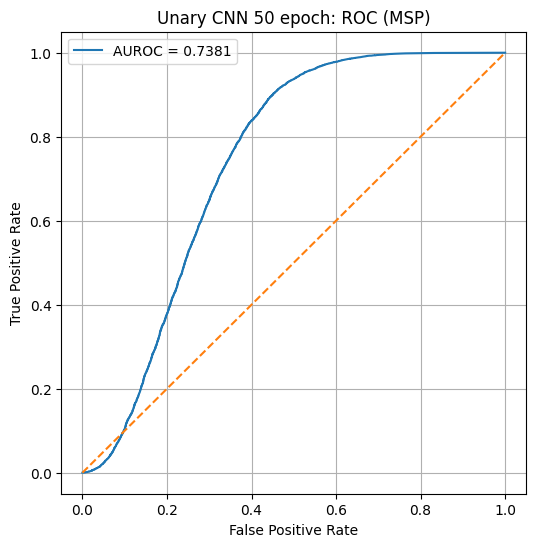

Unary CNN 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.8058
MSP AUROC: 0.7381


In [71]:
unary_id_results_50e = evaluate_model(
    model=model_unary,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_ood_results_50e = evaluate_model(
    model=model_unary,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_metrics_50e = evaluate_ood(
    id_probs=unary_id_results_50e["probs"],
    ood_probs=unary_ood_results_50e["probs"],
    model_name="Unary CNN 50 epoch"
)

Unary CNN 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 13832.54it/s]


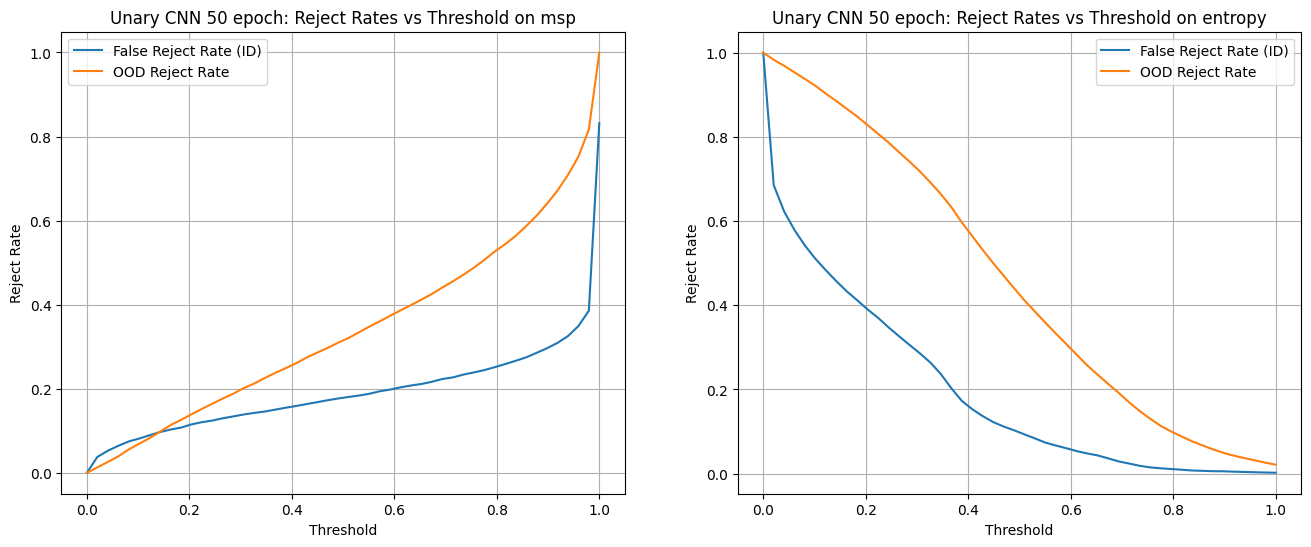

In [72]:
plot_reject_curves(
    id_probs=unary_id_results_50e["probs"],
    ood_probs=unary_ood_results_50e["probs"],
    model_name="Unary CNN 50 epoch"
)

#UNARY MODEL WITH OOD

In [73]:
model_unary_ood = UnaryCNN(num_classes=10).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary_ood.parameters(),
    lr=1e-3
)

fit(
    model=model_unary_ood,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=True,
    ood_ratio = ood_ratio
)

results_unary_ood = evaluate_model(
    model_unary_ood,
    test_loader,
    device,
    mode="onehot"
)

metrics_unary_ood = classification_metrics(
    results_unary_ood["labels"].numpy(),
    results_unary_ood["preds"].numpy()
)

print(metrics_unary_ood["report"])


100%|██████████| 782/782 [00:15<00:00, 50.34it/s, acc=0.361, loss=0.123]


Epoch 1/10 | loss=0.1358 | acc=0.3610


100%|██████████| 782/782 [00:15<00:00, 51.99it/s, acc=0.559, loss=0.108]


Epoch 2/10 | loss=0.1015 | acc=0.5589


100%|██████████| 782/782 [00:14<00:00, 52.16it/s, acc=0.634, loss=0.0689]


...

Epoch 8/10 | loss=0.0620 | acc=0.7716


100%|██████████| 782/782 [00:15<00:00, 49.32it/s, acc=0.788, loss=0.0797]


Epoch 9/10 | loss=0.0585 | acc=0.7876


100%|██████████| 782/782 [00:15<00:00, 50.94it/s, acc=0.798, loss=0.045]


Epoch 10/10 | loss=0.0561 | acc=0.7979
              precision    recall  f1-score   support

           0       0.79      0.74      0.77      1000
           1       0.88      0.80      0.84      1000
           2       0.57      0.70      0.63      1000
           3       0.57      0.56      0.56      1000
           4       0.68      0.68      0.68      1000
           5       0.74      0.52      0.61      1000
           6       0.76      0.81      0.78      1000
           7       0.78      0.77      0.78      1000
           8       0.81      0.88      0.84      1000
           9       0.77      0.85      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



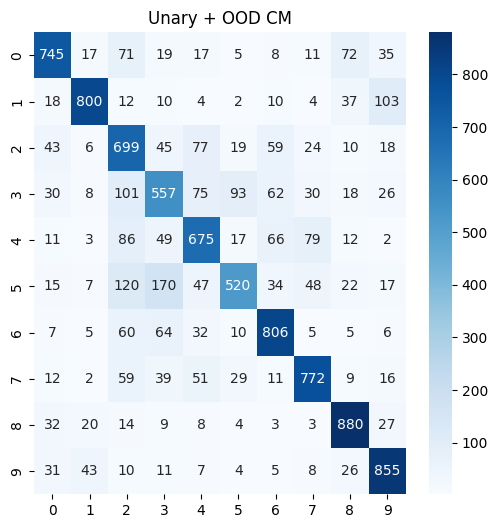

In [74]:
plot_confusion_matrix(metrics_unary_ood["confusion_matrix"], title="Unary + OOD CM")

##EVALUATION

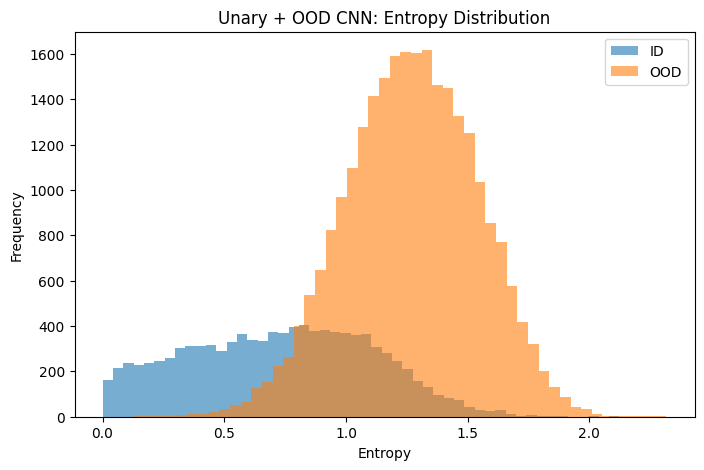

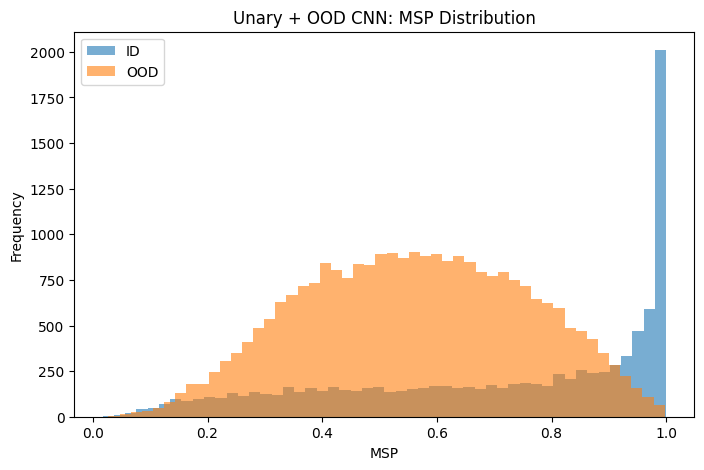

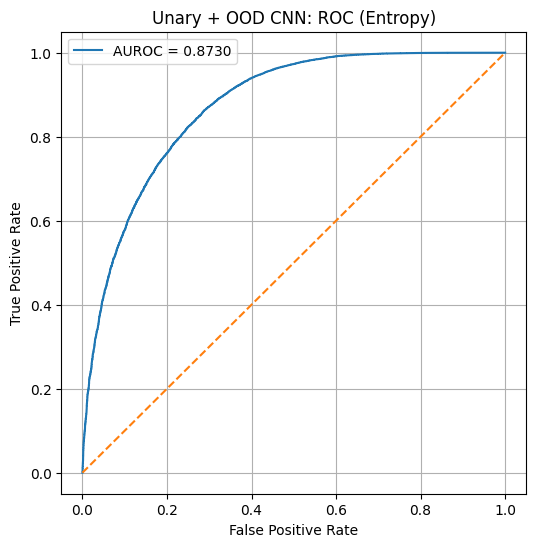

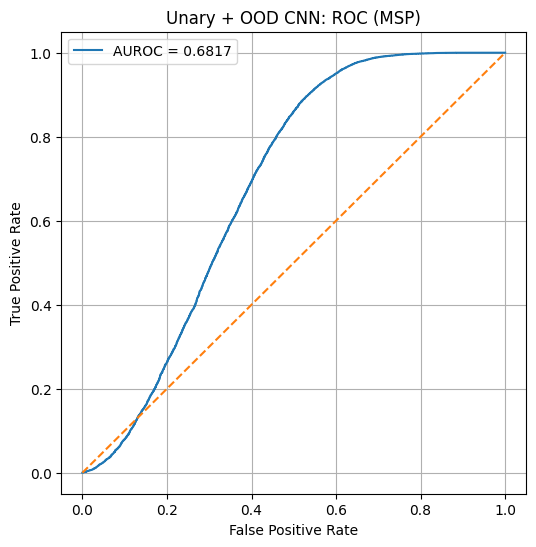

Unary + OOD CNN OOD Metrics
----------------------------------------
Entropy AUROC: 0.8730
MSP AUROC: 0.6817


In [75]:
unary_ood_id_results = evaluate_model(
    model=model_unary_ood,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_ood_ood_results = evaluate_model(
    model=model_unary_ood,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_ood_metrics = evaluate_ood(
    id_probs=unary_ood_id_results["probs"],
    ood_probs=unary_ood_ood_results["probs"],
    model_name="Unary + OOD CNN"
)

Unary + OOD CNN reject curves: 100%|██████████| 50/50 [00:00<00:00, 7479.14it/s]


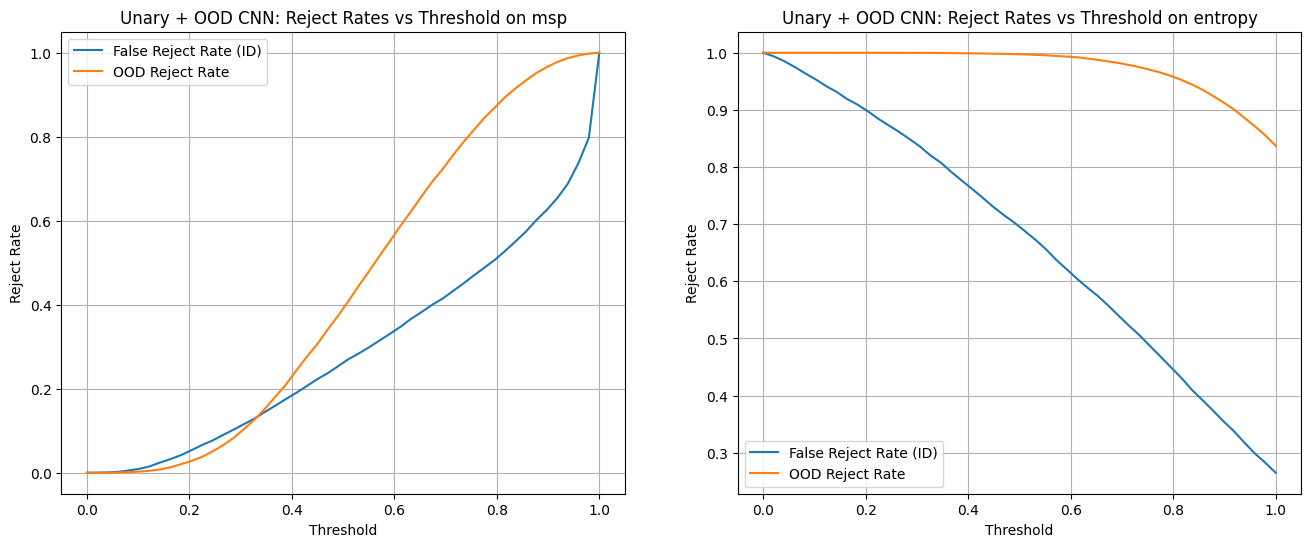

In [76]:
plot_reject_curves(
    id_probs=unary_ood_id_results["probs"],
    ood_probs=unary_ood_ood_results["probs"],
    model_name="Unary + OOD CNN"
)

## Train more epochs

In [77]:
steps, train_steps = 4, 10

fr_list_unary_ood, orr_list_unary_ood = progressive_training_evaluation(
    model_unary_ood,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=True,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)




100%|██████████| 782/782 [00:13<00:00, 56.03it/s, acc=0.799, loss=0.135]


Epoch 1/10 | loss=0.1037 | acc=0.7988


100%|██████████| 782/782 [00:13<00:00, 56.84it/s, acc=0.819, loss=0.098]


Epoch 2/10 | loss=0.0945 | acc=0.8192


100%|██████████| 782/782 [00:13<00:00, 56.60it/s, acc=0.835, loss=0.107]


...

Epoch 9/10 | loss=0.0194 | acc=0.9860


100%|██████████| 782/782 [00:14<00:00, 54.87it/s, acc=0.985, loss=0.0301]


Epoch 10/10 | loss=0.0201 | acc=0.9847


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 8321.04it/s]

step: 4/4: 
	FR = 0.17972
	ORR = 0.45514059618930547


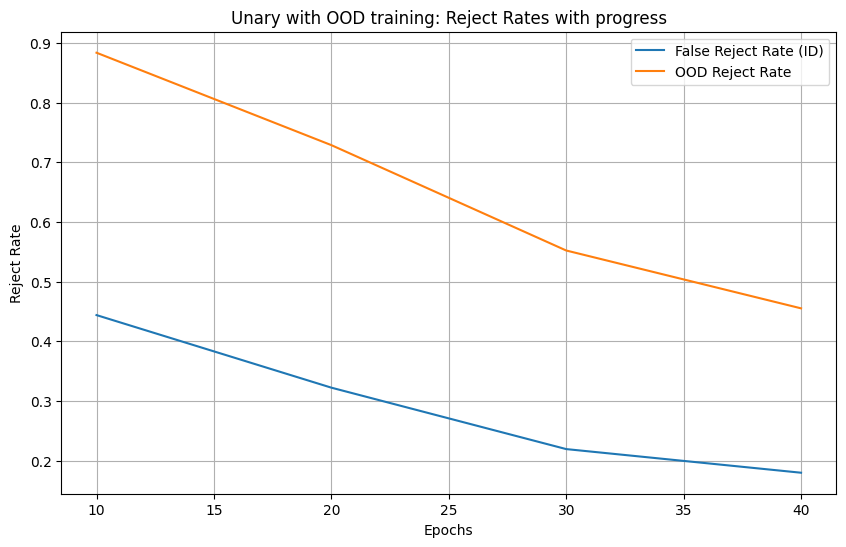

In [78]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary_ood, orr_list_unary_ood, model="Unary with OOD training")

###Evaluation after additional epochs

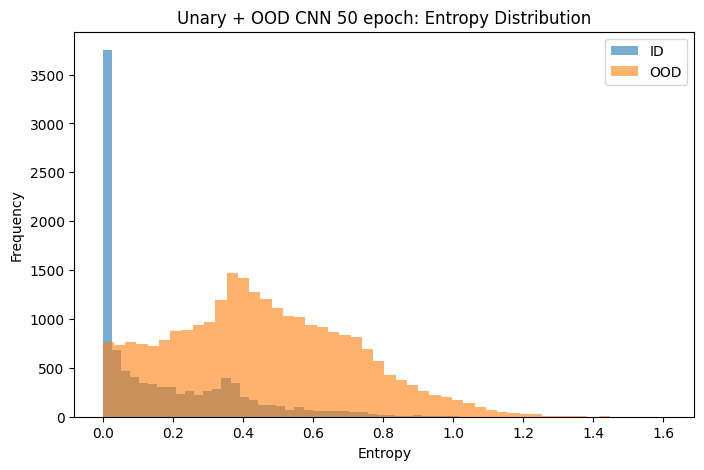

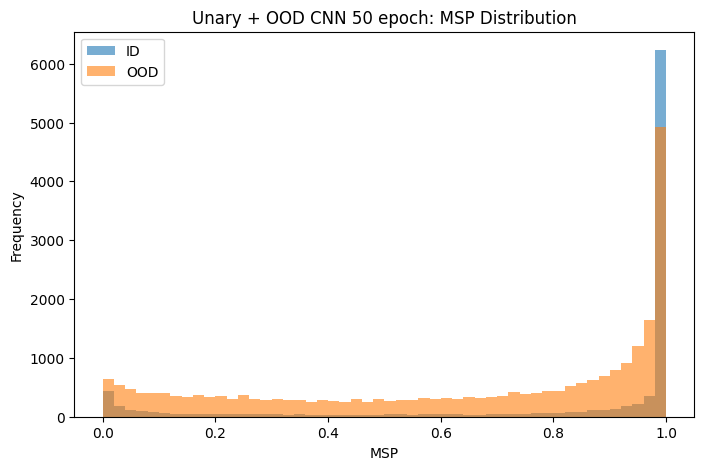

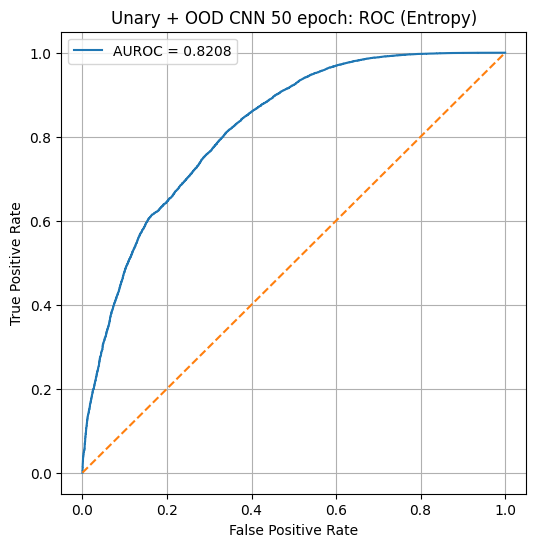

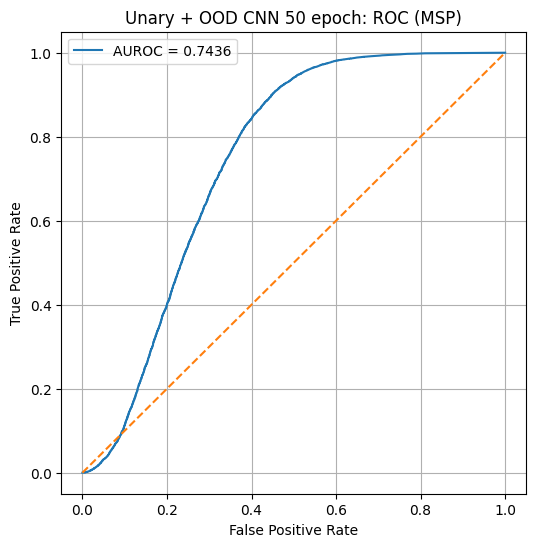

Unary + OOD CNN 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.8208
MSP AUROC: 0.7436


In [79]:
unary_ood_id_results_50e = evaluate_model(
    model=model_unary_ood,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_ood_ood_results_50e = evaluate_model(
    model=model_unary_ood,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_ood_metrics_50e = evaluate_ood(
    id_probs=unary_ood_id_results_50e["probs"],
    ood_probs=unary_ood_ood_results_50e["probs"],
    model_name="Unary + OOD CNN 50 epoch"
)

Unary + OOD CNN 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 10456.48it/s]


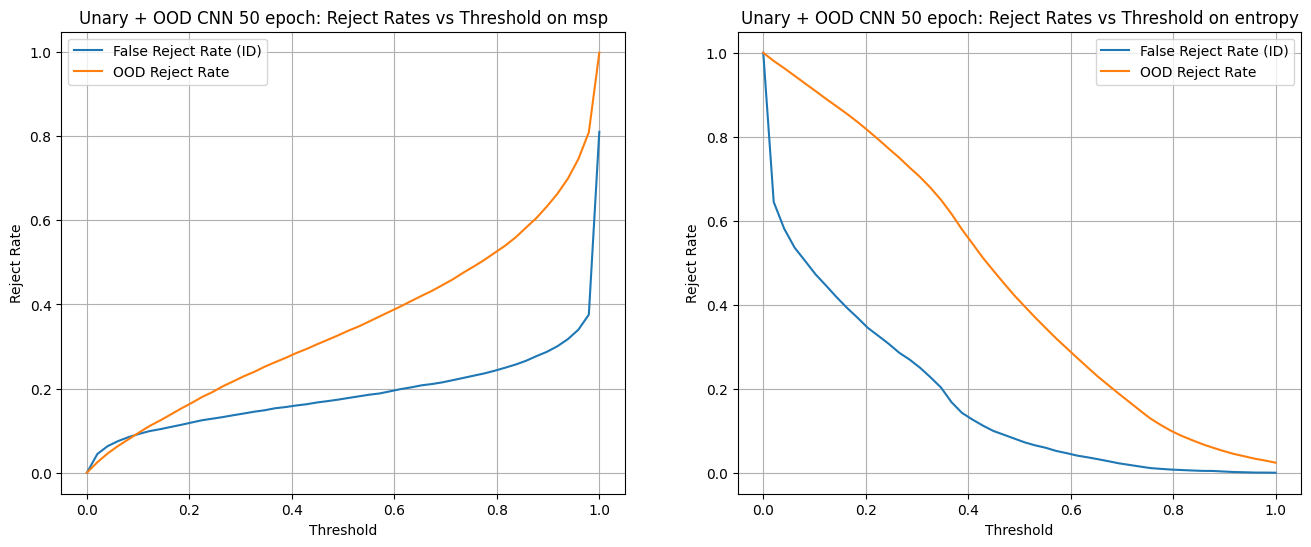

In [80]:
plot_reject_curves(
    id_probs=unary_ood_id_results_50e["probs"],
    ood_probs=unary_ood_ood_results_50e["probs"],
    model_name="Unary + OOD CNN 50 epoch"
)

#UNARY REGULARIZE

In [81]:
class UnaryCNNRegularized(nn.Module):

    def __init__(
        self,
        num_classes=10,
        dropout=0.5
    ):
        super().__init__()

        self.backbone = FeatureCNN()

        self.dropout = nn.Dropout(
            dropout
        )

        self.head = nn.Linear(
            128 * 4 * 4,
            num_classes
        )

    def forward(self, x):

        feats = self.backbone(x)

        feats = self.dropout(feats)

        logits = self.head(feats)

        return logits

In [82]:
model_unary_reg = UnaryCNNRegularized(
    num_classes=10,
    dropout=0.5
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary_reg.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

fit(
    model=model_unary_reg,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=False
)

results_unary_reg = evaluate_model(
    model_unary_reg,
    test_loader,
    device
)

metrics_unary_reg  = classification_metrics(
    results_unary_reg["labels"].numpy(),
    results_unary_reg["preds"].numpy()
)

print(metrics_unary_reg["report"])

100%|██████████| 782/782 [00:13<00:00, 59.03it/s, acc=0.362, loss=0.27]


Epoch 1/10 | loss=0.2647 | acc=0.3621


100%|██████████| 782/782 [00:13<00:00, 57.86it/s, acc=0.515, loss=0.219]


Epoch 2/10 | loss=0.2167 | acc=0.5150


100%|██████████| 782/782 [00:13<00:00, 57.67it/s, acc=0.578, loss=0.162]


...

Epoch 8/10 | loss=0.1550 | acc=0.6921


100%|██████████| 782/782 [00:13<00:00, 57.95it/s, acc=0.701, loss=0.148]


Epoch 9/10 | loss=0.1516 | acc=0.7015


100%|██████████| 782/782 [00:13<00:00, 57.61it/s, acc=0.708, loss=0.156]


Epoch 10/10 | loss=0.1479 | acc=0.7085
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      1000
           1       0.85      0.87      0.86      1000
           2       0.65      0.54      0.59      1000
           3       0.57      0.48      0.52      1000
           4       0.73      0.57      0.64      1000
           5       0.73      0.54      0.62      1000
           6       0.59      0.91      0.72      1000
           7       0.79      0.79      0.79      1000
           8       0.73      0.92      0.82      1000
           9       0.82      0.82      0.82      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



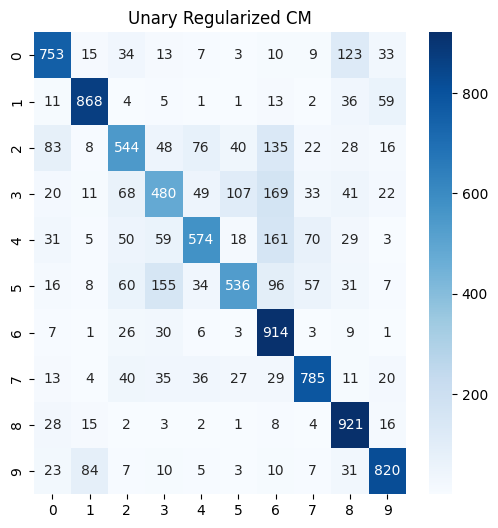

In [83]:
plot_confusion_matrix(metrics_unary_reg["confusion_matrix"], title="Unary Regularized CM")

##Evaluation

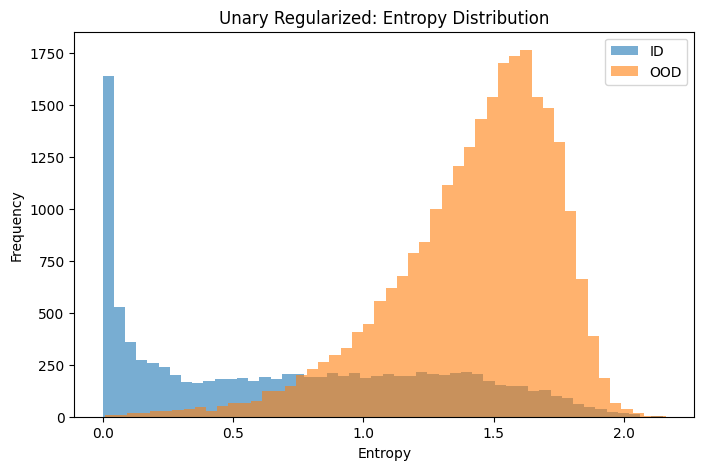

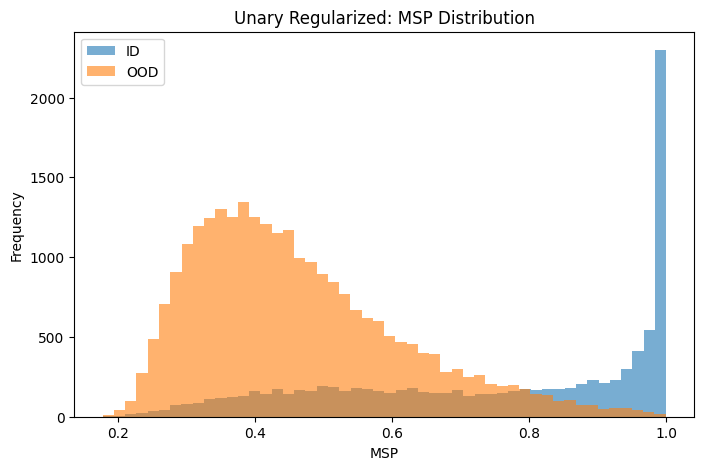

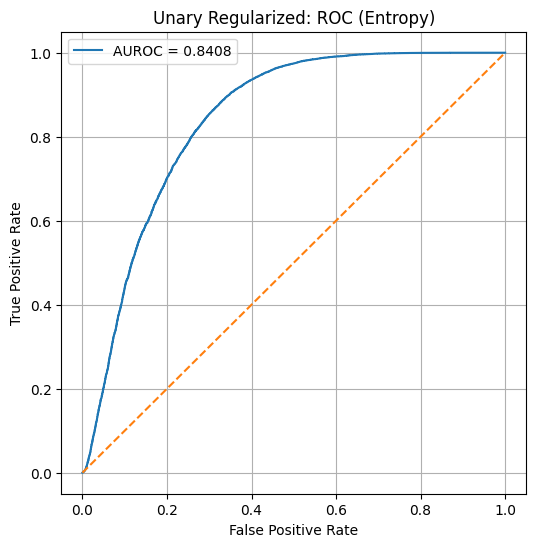

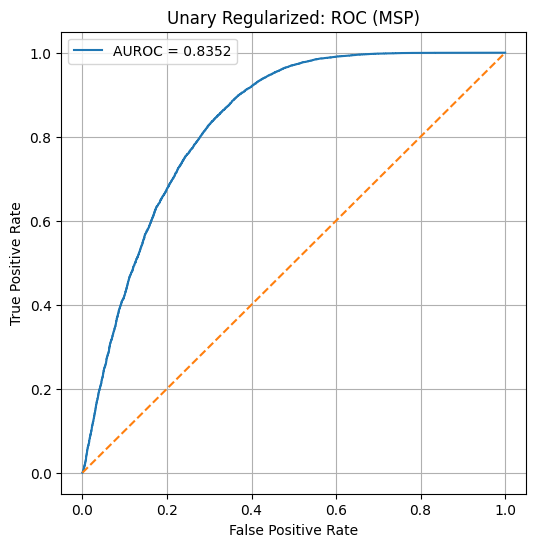

Unary Regularized OOD Metrics
----------------------------------------
Entropy AUROC: 0.8408
MSP AUROC: 0.8352


In [84]:
unary_reg_id_results = evaluate_model(
    model=model_unary_reg,
    loader=test_loader,
    device=device
)

unary_reg_ood_results = evaluate_model(
    model=model_unary_reg,
    loader=svhn_loader,
    device=device
)
unary_reg_metrics = evaluate_ood(
    id_probs=unary_reg_id_results["probs"],
    ood_probs=unary_reg_ood_results["probs"],
    model_name="Unary Regularized"
)

Unary Regularized reject curves: 100%|██████████| 50/50 [00:00<00:00, 10424.78it/s]


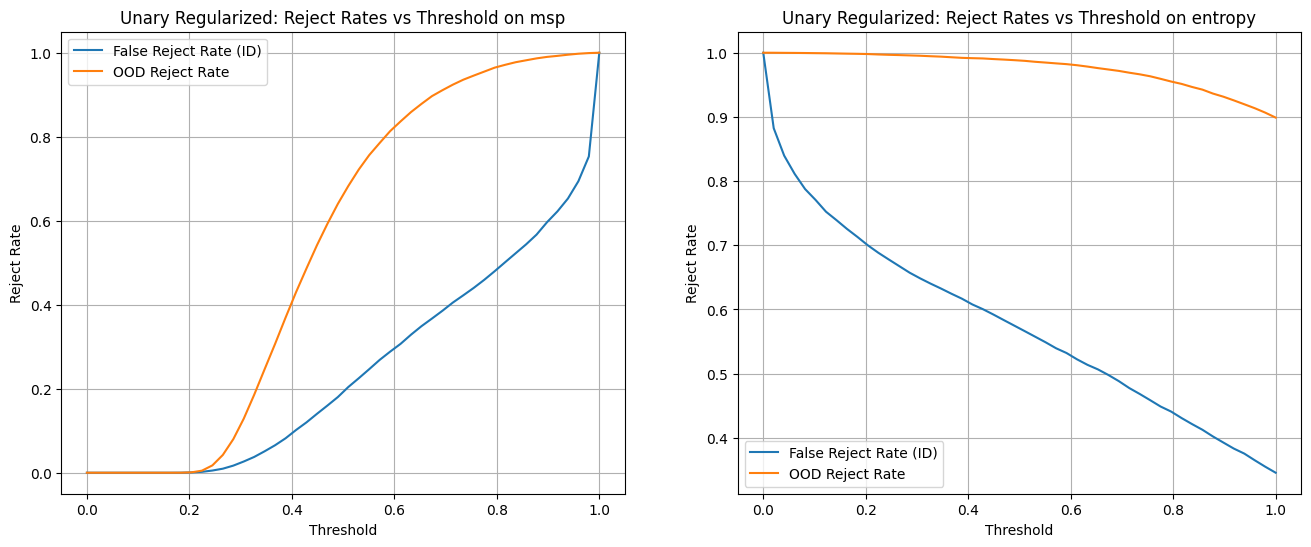

In [85]:
plot_reject_curves(
    id_probs=unary_reg_id_results["probs"],
    ood_probs=unary_reg_ood_results["probs"],
    model_name="Unary Regularized"
)

## Train more epochs

In [86]:
steps, train_steps = 4, 10

fr_list_unary_reg, orr_list_unary_reg = progressive_training_evaluation(
    model_unary_reg,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=False,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)



100%|██████████| 782/782 [00:13<00:00, 58.16it/s, acc=0.714, loss=0.157]


Epoch 1/10 | loss=0.1462 | acc=0.7143


100%|██████████| 782/782 [00:13<00:00, 58.57it/s, acc=0.723, loss=0.175]


Epoch 2/10 | loss=0.1426 | acc=0.7226


100%|██████████| 782/782 [00:13<00:00, 58.12it/s, acc=0.727, loss=0.149]


...

Epoch 9/10 | loss=0.1098 | acc=0.7991


100%|██████████| 782/782 [00:13<00:00, 57.68it/s, acc=0.798, loss=0.0917]


Epoch 10/10 | loss=0.1102 | acc=0.7983


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 9919.36it/s]

step: 4/4: 
	FR = 0.637804
	ORR = 0.9634980024585126


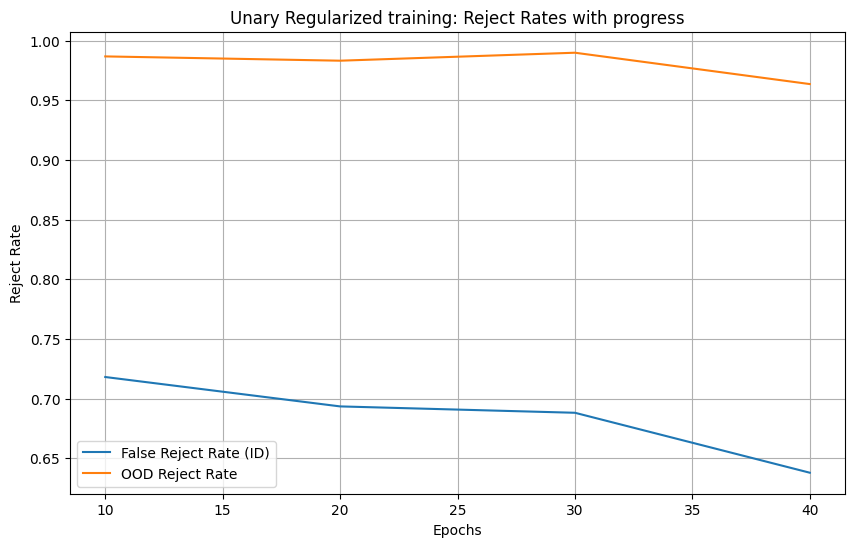

In [87]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary_reg, orr_list_unary_reg, model="Unary Regularized training")

###Evaluation after additional epochs

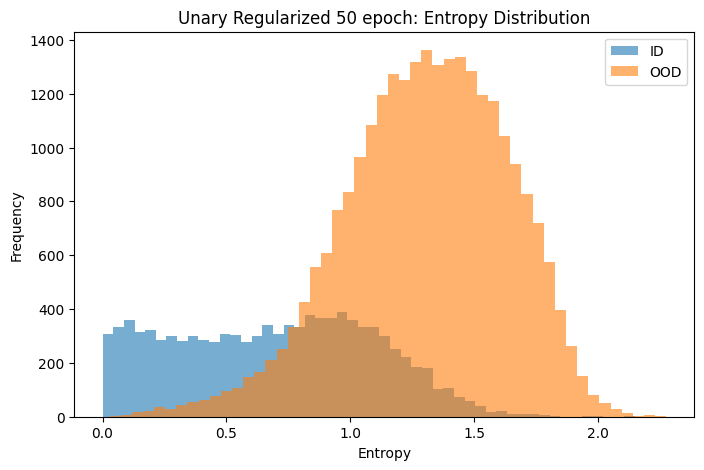

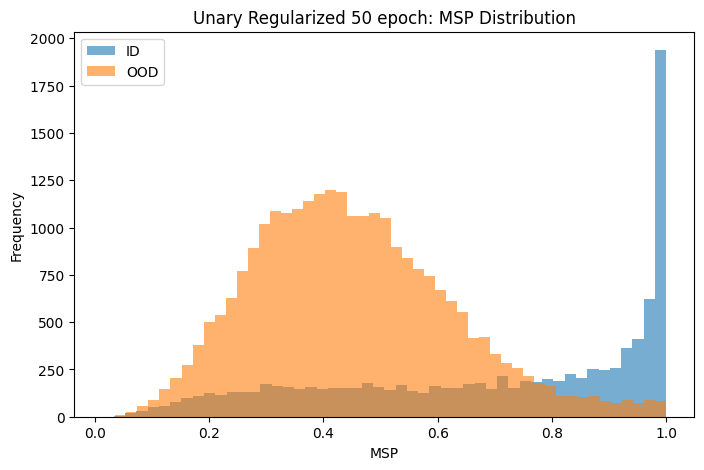

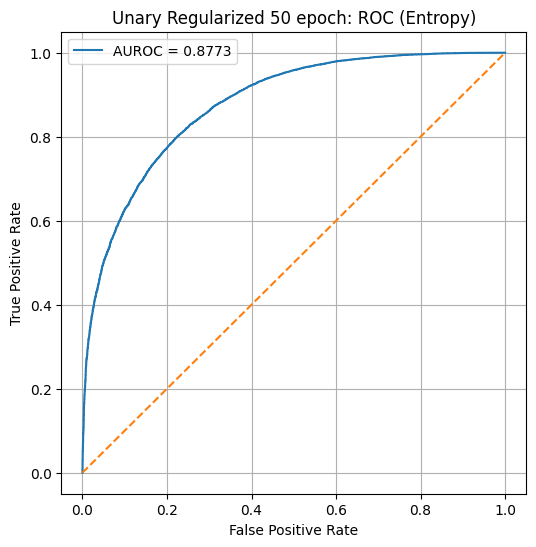

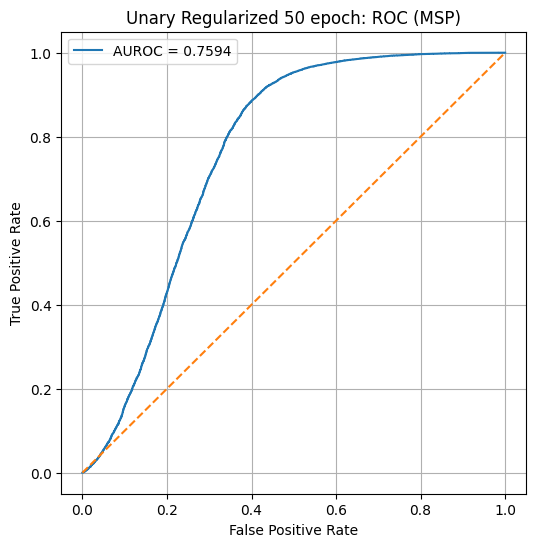

Unary Regularized 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.8773
MSP AUROC: 0.7594


In [88]:
unary_reg_id_results_50e = evaluate_model(
    model=model_unary_reg,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_reg_ood_results_50e = evaluate_model(
    model=model_unary_reg,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_reg_metrics_50e = evaluate_ood(
    id_probs=unary_reg_id_results_50e["probs"],
    ood_probs=unary_reg_ood_results_50e["probs"],
    model_name="Unary Regularized 50 epoch"
)

Unary Regularized 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 11236.95it/s]


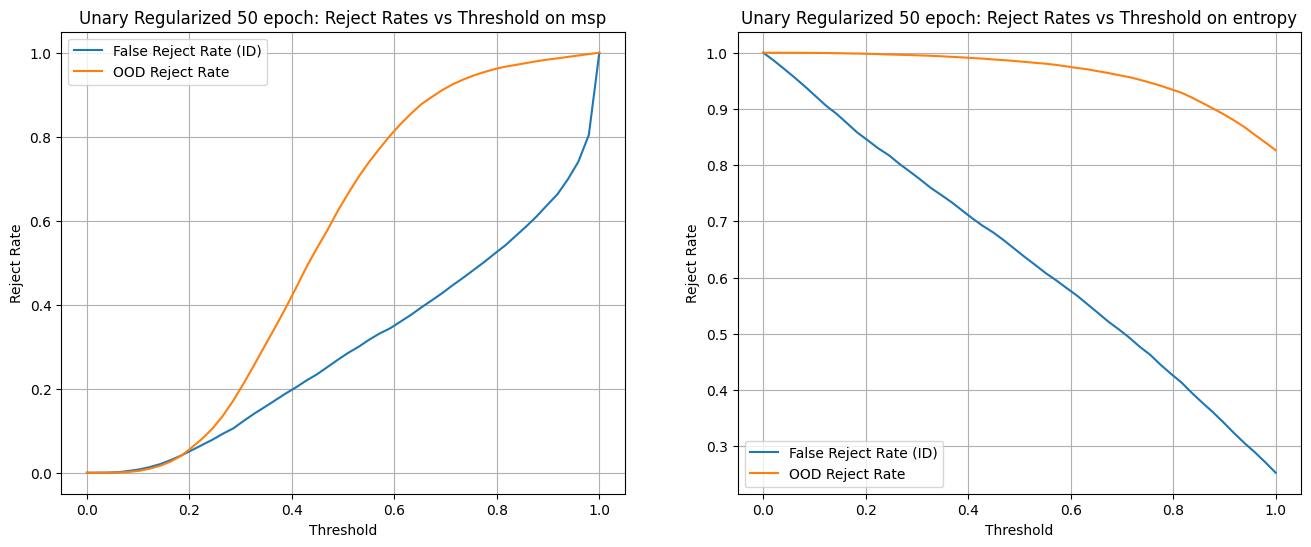

In [89]:
plot_reject_curves(
    id_probs=unary_reg_id_results_50e["probs"],
    ood_probs=unary_reg_ood_results_50e["probs"],
    model_name="Unary Regularized 50 epoch"
)

#UNARY WITH OOD REGULARIZE

In [90]:
model_unary_reg_ood = UnaryCNNRegularized(
    num_classes=10,
    dropout=0.5
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_unary_reg_ood.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

fit(
    model=model_unary_reg_ood,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10,
    mode="onehot",
    use_ood=True
)

results_unary_reg_ood = evaluate_model(
    model_unary_reg_ood,
    test_loader,
    device
)

metrics_unary_reg_ood = classification_metrics(
    results_unary_reg_ood["labels"].numpy(),
    results_unary_reg_ood["preds"].numpy()
)

print(metrics_unary_reg_ood["report"])

100%|██████████| 782/782 [00:14<00:00, 52.19it/s, acc=0.323, loss=0.135]


Epoch 1/10 | loss=0.1408 | acc=0.3227


100%|██████████| 782/782 [00:14<00:00, 52.86it/s, acc=0.484, loss=0.0909]


Epoch 2/10 | loss=0.1136 | acc=0.4836


100%|██████████| 782/782 [00:15<00:00, 52.11it/s, acc=0.545, loss=0.113]


...

Epoch 8/10 | loss=0.0812 | acc=0.6745


100%|██████████| 782/782 [00:15<00:00, 51.13it/s, acc=0.685, loss=0.0799]


Epoch 9/10 | loss=0.0791 | acc=0.6853


100%|██████████| 782/782 [00:15<00:00, 51.48it/s, acc=0.695, loss=0.0851]


Epoch 10/10 | loss=0.0773 | acc=0.6946
              precision    recall  f1-score   support

           0       0.64      0.84      0.72      1000
           1       0.82      0.88      0.85      1000
           2       0.62      0.55      0.58      1000
           3       0.64      0.41      0.50      1000
           4       0.66      0.69      0.68      1000
           5       0.70      0.59      0.64      1000
           6       0.73      0.83      0.77      1000
           7       0.76      0.78      0.77      1000
           8       0.77      0.87      0.82      1000
           9       0.85      0.77      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



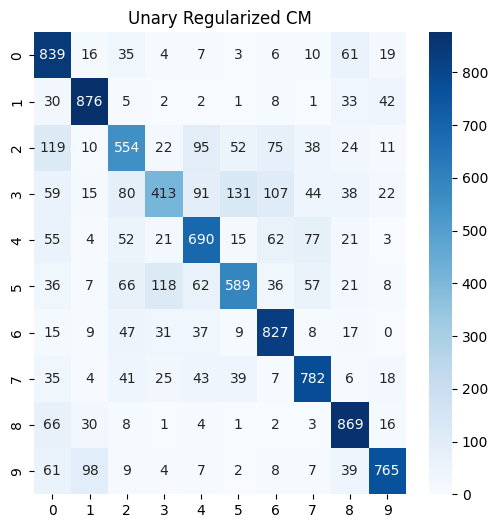

In [91]:
plot_confusion_matrix(metrics_unary_reg_ood["confusion_matrix"], title="Unary Regularized CM")

##Evaluation

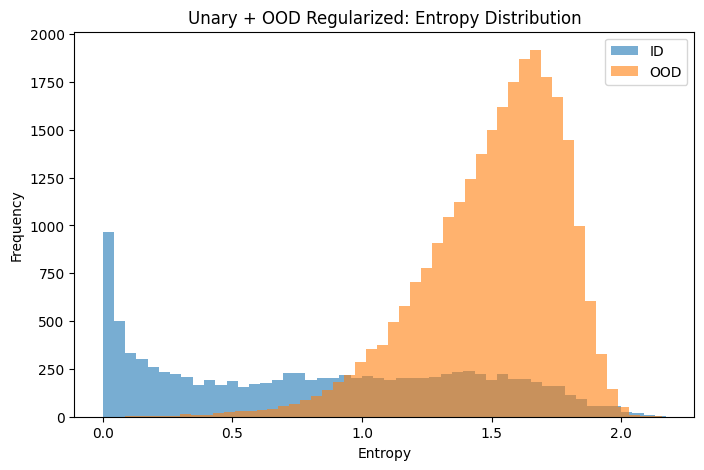

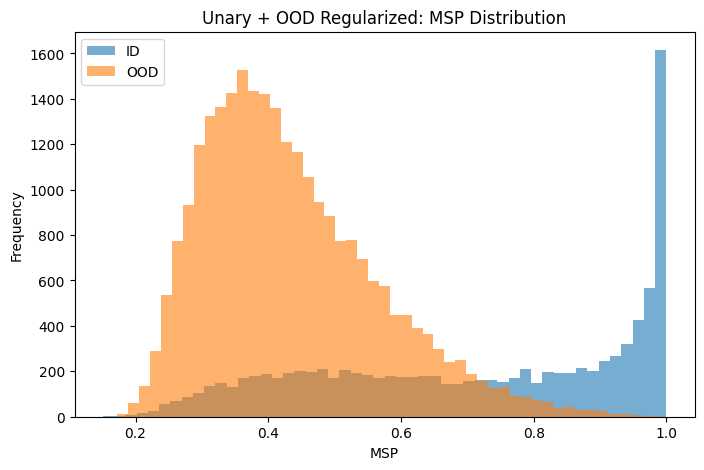

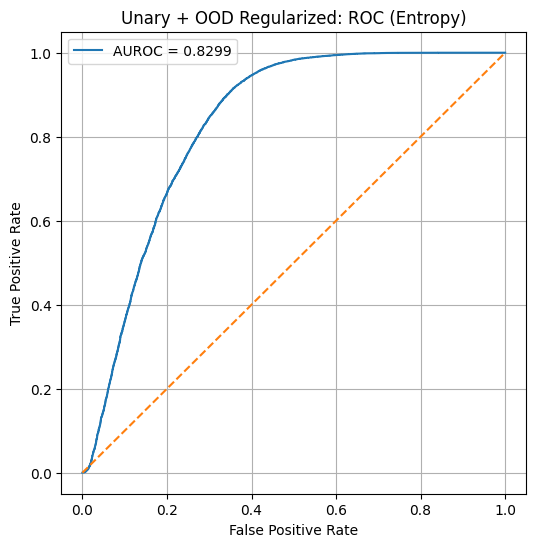

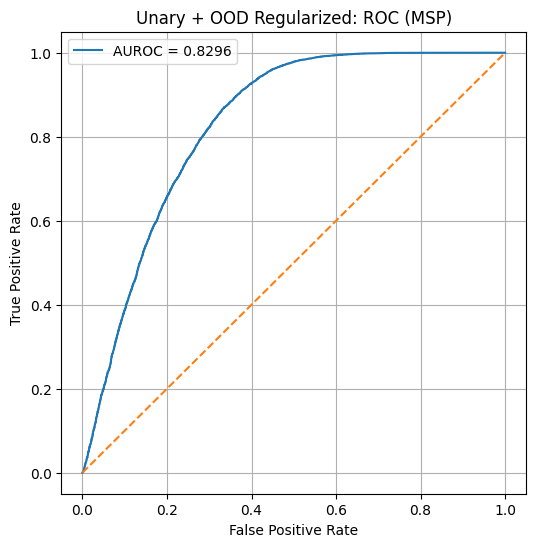

Unary + OOD Regularized OOD Metrics
----------------------------------------
Entropy AUROC: 0.8299
MSP AUROC: 0.8296


In [92]:
unary_reg_ood_id_results = evaluate_model(
    model=model_unary_reg_ood,
    loader=test_loader,
    device=device
)

unary_reg_ood_ood_results = evaluate_model(
    model=model_unary_reg_ood,
    loader=svhn_loader,
    device=device
)
unary_reg_ood_metrics = evaluate_ood(
    id_probs=unary_reg_ood_id_results["probs"],
    ood_probs=unary_reg_ood_ood_results["probs"],
    model_name="Unary + OOD Regularized"
)

Unary + OOD Regularized reject curves: 100%|██████████| 50/50 [00:00<00:00, 12497.18it/s]


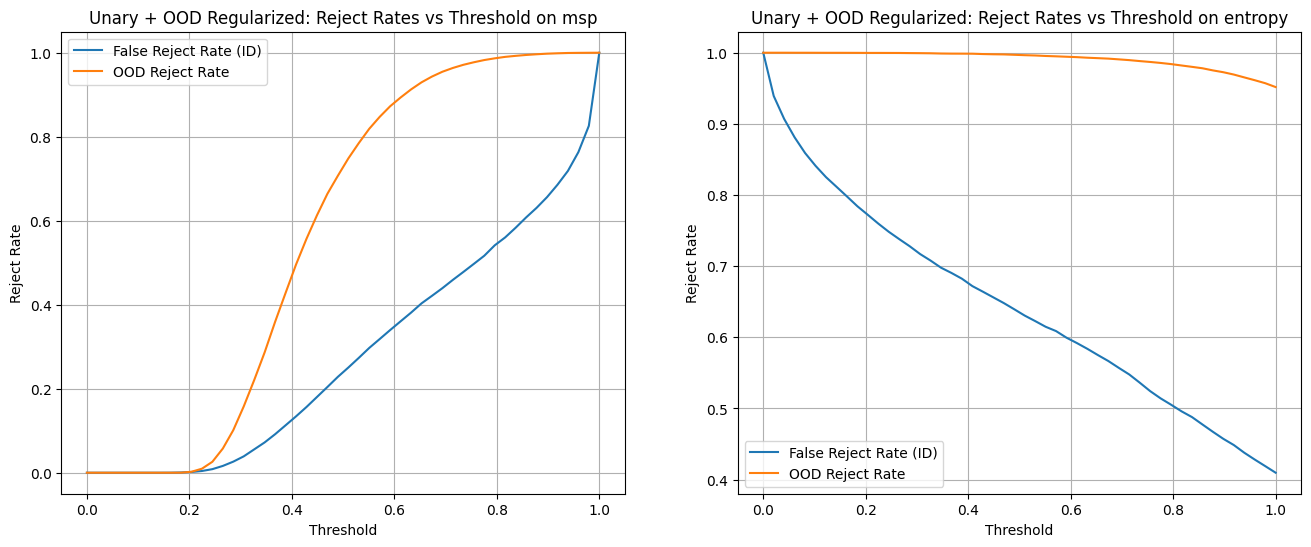

In [93]:
plot_reject_curves(
    id_probs=unary_reg_ood_id_results["probs"],
    ood_probs=unary_reg_ood_ood_results["probs"],
    model_name="Unary + OOD Regularized"
)

## Train more epochs

In [94]:
steps, train_steps = 4, 10

fr_list_unary_reg_ood, orr_list_unary_reg_ood = progressive_training_evaluation(
    model_unary_reg_ood,
    criterion,
    optimizer,
    train_loader,
    test_loader,
    svhn_loader,
    device,
    steps=steps,
    train_steps=train_steps,
    ood_mode=True,
    model_mode='onehot',
    ood_ratio=0.1,
    score_mode="entropy"
)



100%|██████████| 782/782 [00:13<00:00, 56.09it/s, acc=0.696, loss=0.13]


Epoch 1/10 | loss=0.1416 | acc=0.6956


100%|██████████| 782/782 [00:13<00:00, 56.18it/s, acc=0.71, loss=0.147]


Epoch 2/10 | loss=0.1350 | acc=0.7104


100%|██████████| 782/782 [00:13<00:00, 57.07it/s, acc=0.722, loss=0.154]


...

Epoch 9/10 | loss=0.1006 | acc=0.8009


100%|██████████| 782/782 [00:13<00:00, 55.86it/s, acc=0.802, loss=0.0915]


Epoch 10/10 | loss=0.0999 | acc=0.8017


Model reject curves: 100%|██████████| 50/50 [00:00<00:00, 8528.47it/s]

step: 4/4: 
	FR = 0.692248
	ORR = 0.9863275968039337


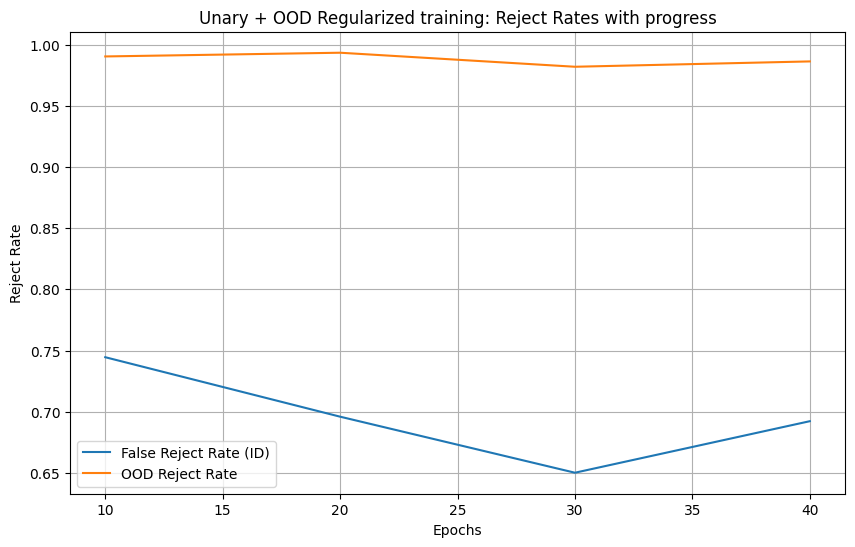

In [95]:
epochs = train_steps, (steps+1)*train_steps, train_steps
plot_reject_rate_by_epochs(epochs, fr_list_unary_reg_ood, orr_list_unary_reg_ood, model="Unary + OOD Regularized training")

###Evaluation after additional epochs

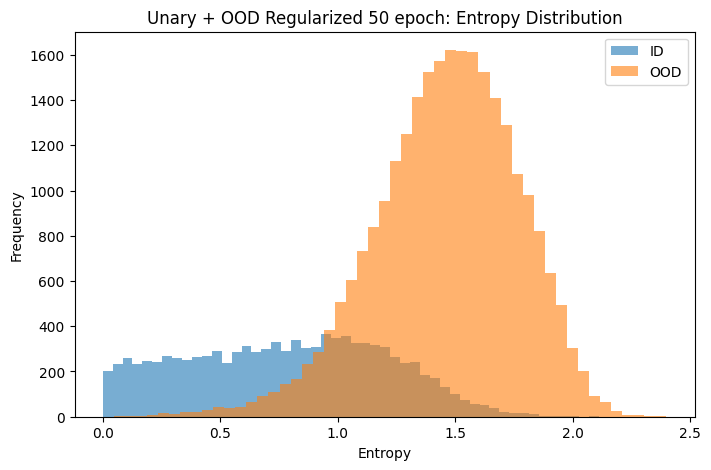

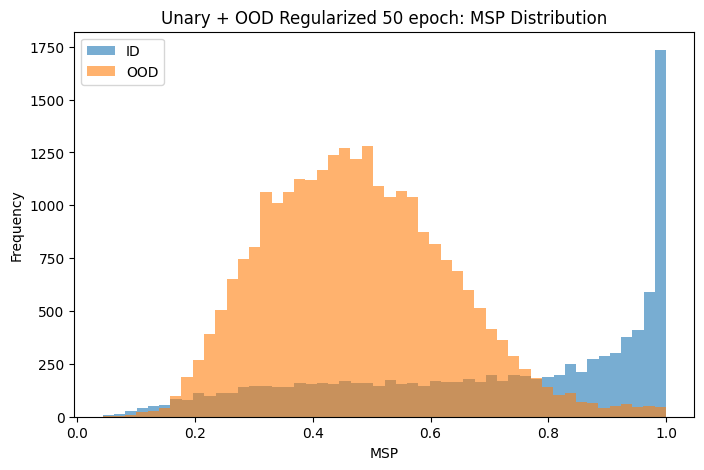

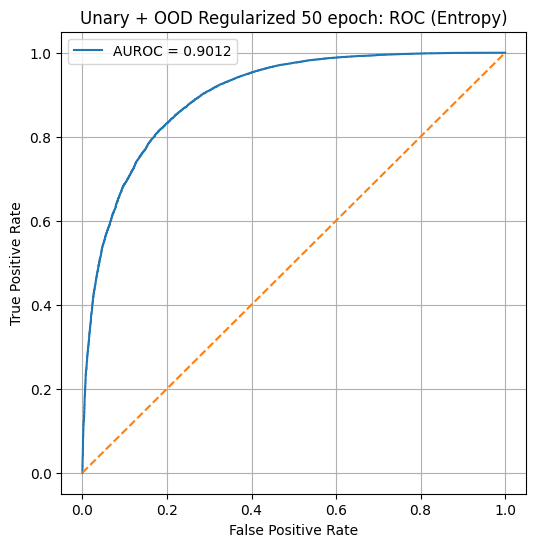

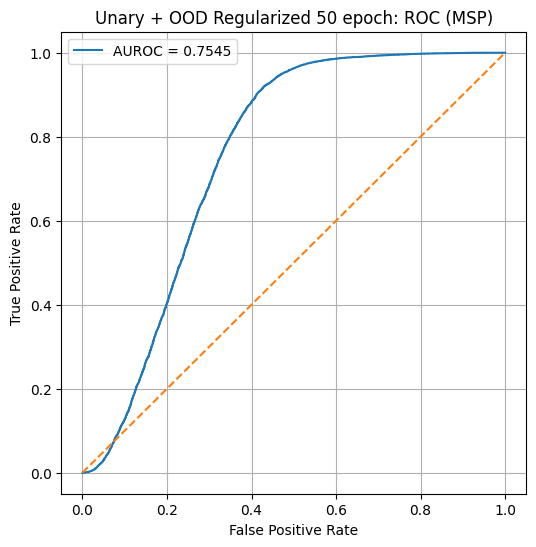

Unary + OOD Regularized 50 epoch OOD Metrics
----------------------------------------
Entropy AUROC: 0.9012
MSP AUROC: 0.7545


In [96]:
unary_reg_ood_id_results_50e = evaluate_model(
    model=model_unary_reg_ood,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_reg_ood_ood_results_50e = evaluate_model(
    model=model_unary_reg_ood,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)
unary_reg_ood_metrics_50e = evaluate_ood(
    id_probs=unary_reg_ood_id_results_50e["probs"],
    ood_probs=unary_reg_ood_ood_results_50e["probs"],
    model_name="Unary + OOD Regularized 50 epoch"
)

Unary + OOD Regularized 50 epoch reject curves: 100%|██████████| 50/50 [00:00<00:00, 11332.89it/s]


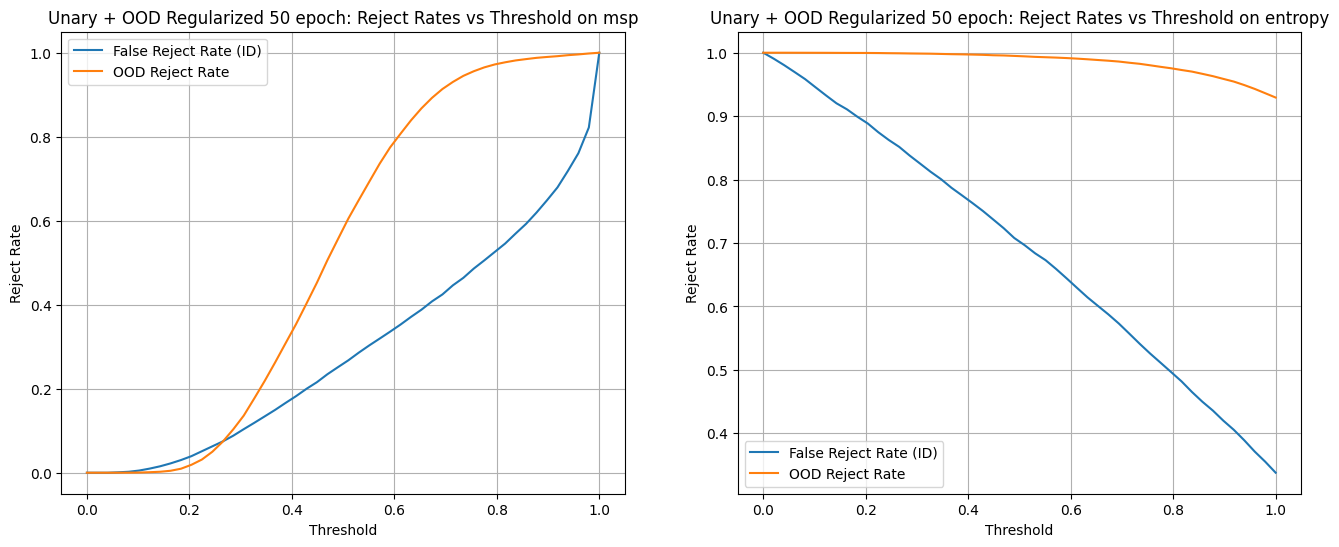

In [97]:
plot_reject_curves(
    id_probs=unary_reg_ood_id_results_50e["probs"],
    ood_probs=unary_reg_ood_ood_results_50e["probs"],
    model_name="Unary + OOD Regularized 50 epoch"
)

#UNARY MODEL WITH AUXILIARY OOD

In [98]:

def train_epoch_unary_with_ood_loader(
    model,
    id_loader,
    ood_loader,
    criterion,
    optimizer,
    device,
    ood_ratio=0.25
):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    ood_iter = iter(ood_loader)

    for x_id, y_id in tqdm(id_loader):

        try:
            x_ood, _ = next(ood_iter)
        except StopIteration:
            ood_iter = iter(ood_loader)
            x_ood, _ = next(ood_iter)

        x_id = x_id.to(device)
        y_id = y_id.to(device)
        x_ood = x_ood.to(device)

        ood_batch_size = max(
            1,
            min(
                x_ood.size(0),
                int(x_id.size(0) * ood_ratio)
            )
        )

        x_ood = x_ood[:ood_batch_size]

        y_id_targets = F.one_hot(
            y_id,
            num_classes=model.head.out_features
        ).float()


        y_ood_targets = torch.zeros(
            ood_batch_size,
            model.head.out_features,
            device=device
        )


        x = torch.cat(
            [x_id, x_ood],
            dim=0
        )

        y = torch.cat(
            [y_id_targets, y_ood_targets],
            dim=0
        )



        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()



        probs_id = torch.sigmoid(
            logits[:x_id.size(0)]
        )

        preds_id = probs_id.argmax(dim=1)

        correct += (
            preds_id == y_id
        ).sum().item()

        total += y_id.size(0)

        total_loss += loss.item()

    return {
        "loss": total_loss / len(id_loader),
        "acc": correct / total
    }


def fit_unary_with_ood_loader(
    model,
    id_loader,
    ood_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    ood_ratio=0.25
):

    history = []

    for epoch in range(epochs):

        metrics = train_epoch_unary_with_ood_loader(
            model=model,
            id_loader=id_loader,
            ood_loader=ood_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            ood_ratio=ood_ratio
        )

        history.append(metrics)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"loss={metrics['loss']:.4f} | "
            f"acc={metrics['acc']:.4f}"
        )

    return history



model_unary_cifar100_ood = UnaryCNN(
    num_classes=10
).to(device)


criterion_unary_cifar100_ood = nn.BCEWithLogitsLoss()


optimizer_unary_cifar100_ood = torch.optim.Adam(
    model_unary_cifar100_ood.parameters(),
    lr=1e-3
)



history_unary_cifar100_ood = fit_unary_with_ood_loader(
    model=model_unary_cifar100_ood,
    id_loader=train_loader,
    ood_loader=cifar100_train_loader,
    criterion=criterion_unary_cifar100_ood,
    optimizer=optimizer_unary_cifar100_ood,
    device=device,
    epochs=10,
    ood_ratio=0.25
)

100%|██████████| 782/782 [00:19<00:00, 40.77it/s]


Epoch 1/10 | loss=0.2230 | acc=0.3999


100%|██████████| 782/782 [00:19<00:00, 39.40it/s]


Epoch 2/10 | loss=0.1766 | acc=0.5754


100%|██████████| 782/782 [00:19<00:00, 39.31it/s]


...

Epoch 8/10 | loss=0.1133 | acc=0.7851


100%|██████████| 782/782 [00:19<00:00, 40.26it/s]


Epoch 9/10 | loss=0.1081 | acc=0.7996


100%|██████████| 782/782 [00:19<00:00, 40.67it/s]

Epoch 10/10 | loss=0.1043 | acc=0.8081


In [99]:
results_unary_cifar100_ood = evaluate_model(
    model_unary_cifar100_ood,
    test_loader,
    device,
    mode="onehot"
)

metrics_unary_cifar100_ood = classification_metrics(
    results_unary_cifar100_ood["labels"].numpy(),
    results_unary_cifar100_ood["preds"].numpy()
)

print(metrics_unary_cifar100_ood["report"])

              precision    recall  f1-score   support

           0       0.83      0.73      0.77      1000
           1       0.88      0.84      0.86      1000
           2       0.65      0.64      0.64      1000
           3       0.58      0.55      0.57      1000
           4       0.78      0.65      0.71      1000
           5       0.58      0.74      0.65      1000
           6       0.71      0.88      0.79      1000
           7       0.84      0.76      0.80      1000
           8       0.82      0.88      0.85      1000
           9       0.85      0.82      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



In [100]:
unary_cifar100_ood_id_results = evaluate_model(
    model=model_unary_cifar100_ood,
    loader=test_loader,
    device=device,
    mode="onehot"
)

unary_cifar100_ood_svhn_results = evaluate_model(
    model=model_unary_cifar100_ood,
    loader=svhn_loader,
    device=device,
    mode="onehot"
)

unary_cifar100_ood_cifar100_results = evaluate_model(
    model=model_unary_cifar100_ood,
    loader=cifar100_test_loader,
    device=device,
    mode="onehot"
)


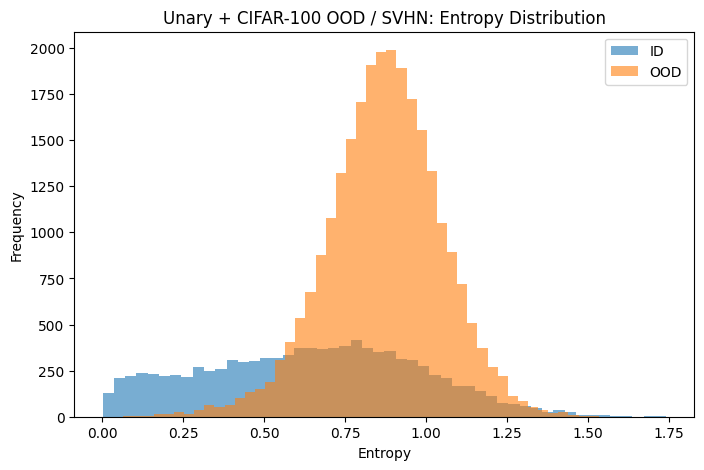

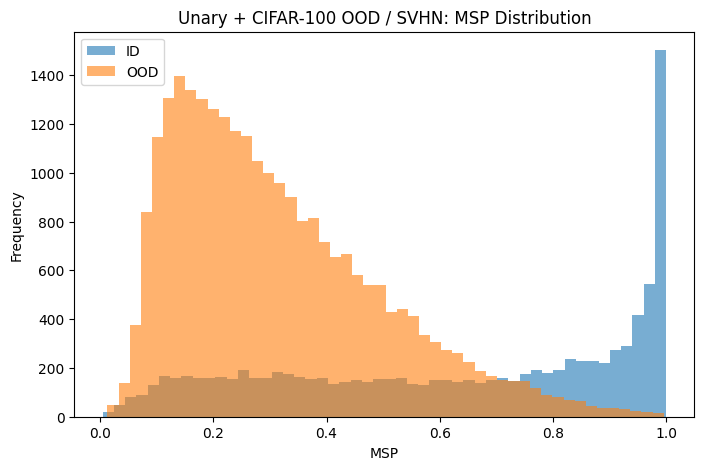

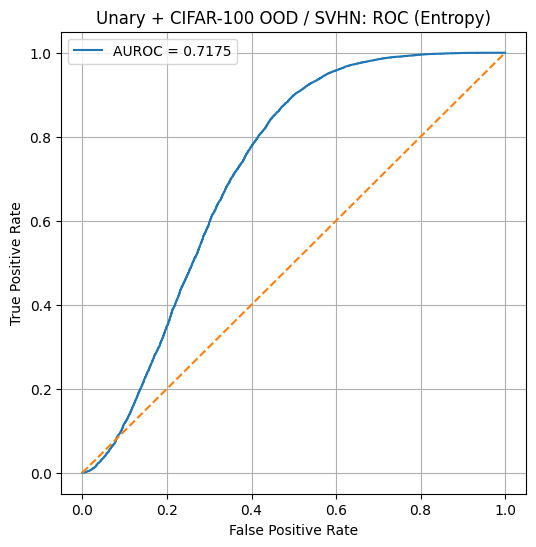

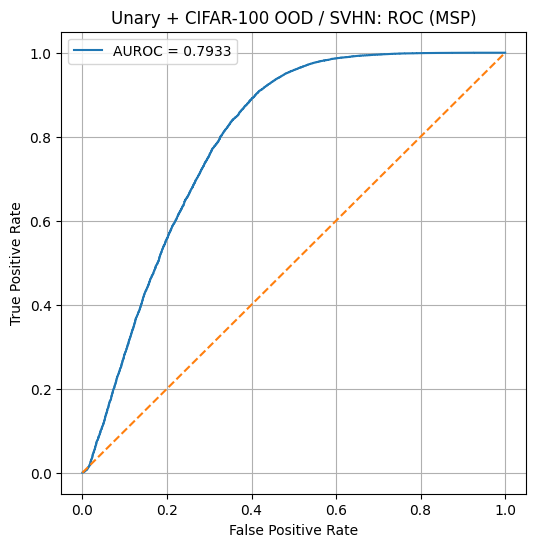

Unary + CIFAR-100 OOD / SVHN OOD Metrics
----------------------------------------
Entropy AUROC: 0.7175
MSP AUROC: 0.7933


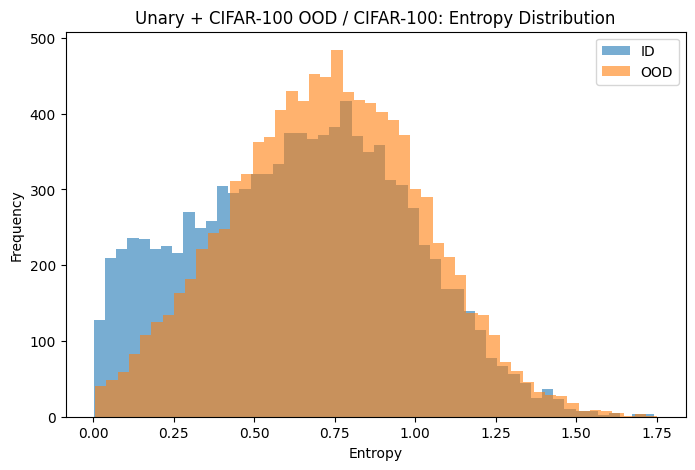

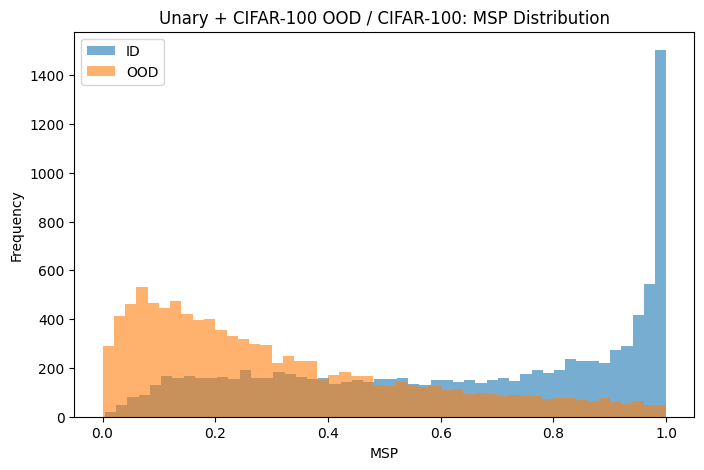

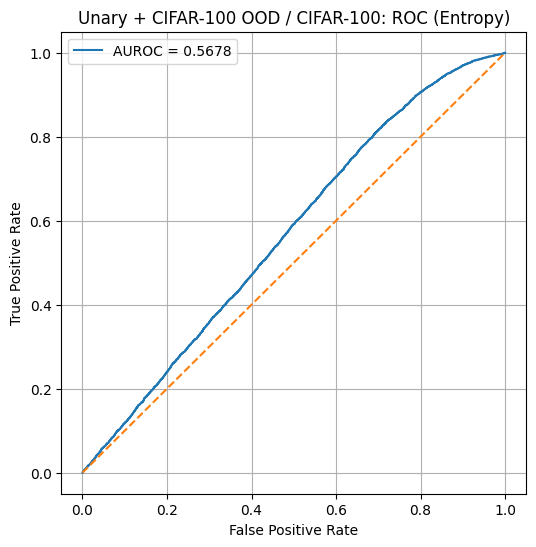

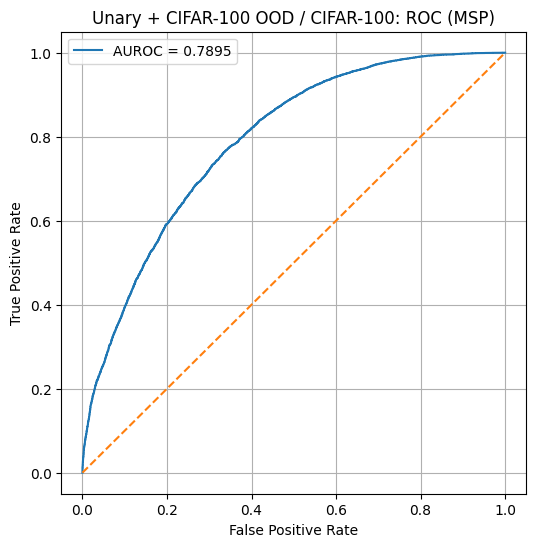

Unary + CIFAR-100 OOD / CIFAR-100 OOD Metrics
----------------------------------------
Entropy AUROC: 0.5678
MSP AUROC: 0.7895


In [101]:
unary_cifar100_ood_svhn_metrics = evaluate_ood(
    id_probs=unary_cifar100_ood_id_results["probs"],
    ood_probs=unary_cifar100_ood_svhn_results["probs"],
    model_name="Unary + CIFAR-100 OOD / SVHN"
)

unary_cifar100_ood_cifar100_metrics = evaluate_ood(
    id_probs=unary_cifar100_ood_id_results["probs"],
    ood_probs=unary_cifar100_ood_cifar100_results["probs"],
    model_name="Unary + CIFAR-100 OOD / CIFAR-100"
)

#Results

## Energy and ODIN across all model configurations

In [102]:
def compute_energy(logits, temperature=1.0):
    return -temperature * torch.logsumexp(logits / temperature, dim=1)


def get_logits(model, loader, device):
    model.eval()
    logits_all = []
    with torch.no_grad():
        for x, _ in loader:
            logits_all.append(model(x.to(device)).detach().cpu())
    return torch.cat(logits_all)


def compute_auroc(id_scores, ood_scores):
    labels = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    scores = np.concatenate([id_scores, ood_scores])
    return roc_auc_score(labels, scores)


def odin_scores(model, loader, device, temperature=1000.0, epsilon=0.0014):
    model.eval()
    scores = []
    for x, _ in loader:
        x = x.to(device)
        x.requires_grad_(True)
        logits = model(x)
        scaled_logits = logits / temperature
        pseudo_labels = scaled_logits.argmax(dim=1)
        loss = F.cross_entropy(scaled_logits, pseudo_labels)
        model.zero_grad(set_to_none=True)
        loss.backward()
        gradient = x.grad.detach().sign()
        x_perturbed = (x.detach() - epsilon * gradient).clamp(0.0, 1.0)
        with torch.no_grad():
            perturbed_logits = model(x_perturbed)
            probs = torch.softmax(perturbed_logits / temperature, dim=1)
            scores.append(probs.max(dim=1).values.cpu())
        model.zero_grad(set_to_none=True)
    return torch.cat(scores).numpy()


def evaluate_energy_odin(model, id_loader, ood_loader, device,
                         energy_temperature=1.0,
                         odin_temperature=1000.0,
                         odin_epsilon=0.0014):
    id_logits = get_logits(model, id_loader, device)
    ood_logits = get_logits(model, ood_loader, device)
    id_energy = compute_energy(id_logits, energy_temperature).numpy()
    ood_energy = compute_energy(ood_logits, energy_temperature).numpy()
    energy_auroc = compute_auroc(id_energy, ood_energy)

    id_odin = odin_scores(model, id_loader, device, odin_temperature, odin_epsilon)
    ood_odin = odin_scores(model, ood_loader, device, odin_temperature, odin_epsilon)
    odin_auroc = compute_auroc(-id_odin, -ood_odin)

    return energy_auroc, odin_auroc

all_torch_models = {
    "Baseline CNN": basemodel,
    "Bayesian CNN": bayes_model,
    "Baseline + OOD class": basemodel_OOD,
    "Bayesian + OOD class": bayes_OOD,
    "Unary CNN": model_unary,
    "Unary + OOD CNN": model_unary_ood,
    "Unary + CIFAR-100 OOD": model_unary_cifar100_ood,
    "Unary Regularized": model_unary_reg,
    "Unary + OOD Regularized": model_unary_reg_ood,
}

ood_loaders = {
    "SVHN": svhn_loader,
    "CIFAR-100": cifar100_test_loader,
}

modern_rows = []

for model_name, model in all_torch_models.items():
    print(f"\n{'=' * 70}\n{model_name}\n{'=' * 70}")
    row = {"Model": model_name}

    for ood_name, ood_loader in ood_loaders.items():
        energy_auc, odin_auc = evaluate_energy_odin(
            model=model,
            id_loader=test_loader,
            ood_loader=ood_loader,
            device=device,
            energy_temperature=1.0,
            odin_temperature=1000.0,
            odin_epsilon=0.0014,
        )
        row[f"Energy AUROC ({ood_name})"] = energy_auc
        row[f"ODIN AUROC ({ood_name})"] = odin_auc
        print(f"{ood_name:10s} | Energy AUROC = {energy_auc:.4f} | ODIN AUROC = {odin_auc:.4f}")

    modern_rows.append(row)

modern_all_results = pd.DataFrame(modern_rows)
format_dict = {
    column: "{:.4f}"
    for column in modern_all_results.columns
    if column != "Model"
}
display(modern_all_results.style.format(format_dict))



Baseline CNN
SVHN       | Energy AUROC = 0.7858 | ODIN AUROC = 0.8849
CIFAR-100  | Energy AUROC = 0.7416 | ODIN AUROC = 0.7360

Bayesian CNN
SVHN       | Energy AUROC = 0.2853 | ODIN AUROC = 0.7967
CIFAR-100  | Energy AUROC = 0.4504 | ODIN AUROC = 0.7272

Baseline + OOD class
SVHN       | Energy AUROC = 0.6633 | ODIN AUROC = 0.8736
CIFAR-100  | Energy AUROC = 0.7331 | ODIN AUROC = 0.7288

Bayesian + OOD class
SVHN       | Energy AUROC = 0.2014 | ODIN AUROC = 0.7701
CIFAR-100  | Energy AUROC = 0.4315 | ODIN AUROC = 0.7113

Unary CNN
SVHN       | Energy AUROC = 0.7355 | ODIN AUROC = 0.8883
CIFAR-100  | Energy AUROC = 0.6980 | ODIN AUROC = 0.7159

Unary + OOD CNN
SVHN       | Energy AUROC = 0.7405 | ODIN AUROC = 0.9121
CIFAR-100  | Energy AUROC = 0.6953 | ODIN AUROC = 0.7194

Unary + CIFAR-100 OOD
SVHN       | Energy AUROC = 0.7902 | ODIN AUROC = 0.8137
CIFAR-100  | Energy AUROC = 0.7932 | ODIN AUROC = 0.7468

Unary Regularized
SVHN       | Energy AUROC = 0.7169 | ODIN AUROC = 0.8528
CIF

,Model,Energy AUROC (SVHN),ODIN AUROC (SVHN),Energy AUROC (CIFAR-100),ODIN AUROC (CIFAR-100)
0,Baseline CNN,0.7858,0.8849,0.7416,0.7360
1,Bayesian CNN,0.2853,0.7967,0.4504,0.7272
2,Baseline + OOD class,0.6633,0.8736,0.7331,0.7288
3,Bayesian + OOD class,0.2014,0.7701,0.4315,0.7113
4,Unary CNN,0.7355,0.8883,0.6980,0.7159
5,Unary + OOD CNN,0.7405,0.9121,0.6953,0.7194
6,Unary + CIFAR-100 OOD,0.7902,0.8137,0.7932,0.7468
7,Unary Regularized,0.7169,0.8528,0.7571,0.7743
8,Unary + OOD Regularized,0.7063,0.8664,0.7527,0.7678


## Near-OOD evaluation: CIFAR-100

In [103]:
near_ood_specs = {
    "Baseline CNN": (basemodel, "softmax"),
    "Bayesian CNN": (bayes_model, "softmax"),
    "Baseline + OOD class": (basemodel_OOD, "softmax"),
    "Bayesian + OOD class": (bayes_OOD, "softmax"),
    "Unary CNN": (model_unary, "onehot"),
    "Unary + OOD CNN": (model_unary_ood, "onehot"),
    "Unary + CIFAR-100 OOD": (model_unary_cifar100_ood, "onehot"),
    "Unary Regularized": (model_unary_reg, "onehot"),
    "Unary + OOD Regularized": (model_unary_reg_ood, "onehot")
}


near_ood_rows = []

for model_name, (model, mode) in near_ood_specs.items():

    id_results = evaluate_model(
        model,
        test_loader,
        device,
        mode=mode
    )

    ood_results = evaluate_model(
        model,
        cifar100_test_loader,
        device,
        mode=mode
    )

    metrics = compute_ood_metrics(
        id_results["probs"],
        ood_results["probs"]
    )

    near_ood_rows.append({
        "Model": model_name,
        "MSP AUROC": metrics["msp"]["auroc"],
        "Entropy AUROC": metrics["entropy"]["auroc"]
    })


near_ood_results = pd.DataFrame(
    near_ood_rows
)

display(
    near_ood_results.reset_index(drop=True)
)

,Model,MSP AUROC,Entropy AUROC
0,Baseline CNN,0.711227,0.725892
1,Bayesian CNN,0.687014,0.705343
2,Baseline + OOD class,0.708901,0.722440
3,Bayesian + OOD class,0.684410,0.701912
4,Unary CNN,0.697642,0.649913
5,Unary + OOD CNN,0.695232,0.654008
6,Unary + CIFAR-100 OOD,0.789512,0.567802
7,Unary Regularized,0.763659,0.742635
8,Unary + OOD Regularized,0.759746,0.738478


## OOD COMPARISON

In [104]:

comparison_models = {
    "Baseline CNN": basemodel,

    "Baseline + CIFAR-100 OOD": (
        basemodel_OOD_CIFAR100
    ),

    "Unary CNN": model_unary,

    "Unary + CIFAR-100 OOD": (
        model_unary_cifar100_ood
    ),
}


comparison_rows = []


for model_name, model in comparison_models.items():

    row = {
        "Model": model_name
    }

    for ood_name, ood_loader in {
        "SVHN": svhn_loader,
        "CIFAR-100": cifar100_test_loader
    }.items():

        energy_auc, odin_auc = evaluate_energy_odin(
            model=model,
            id_loader=test_loader,
            ood_loader=ood_loader,
            device=device,
            energy_temperature=1.0,
            odin_temperature=1000.0,
            odin_epsilon=0.0014
        )

        row[
            f"Energy AUROC ({ood_name})"
        ] = energy_auc

        row[
            f"ODIN AUROC ({ood_name})"
        ] = odin_auc

    comparison_rows.append(row)


comparison_results = pd.DataFrame(
    comparison_rows
)


format_dict = {
    column: "{:.4f}"
    for column in comparison_results.columns
    if column != "Model"
}


display(
    comparison_results.style.format(format_dict)
)

,Model,Energy AUROC (SVHN),ODIN AUROC (SVHN),Energy AUROC (CIFAR-100),ODIN AUROC (CIFAR-100)
0,Baseline CNN,0.7858,0.8849,0.7416,0.7360
1,Baseline + CIFAR-100 OOD,0.5809,0.7123,0.6731,0.6592
2,Unary CNN,0.7355,0.8883,0.6980,0.7159
3,Unary + CIFAR-100 OOD,0.7902,0.8137,0.7932,0.7468
